# Frouth Stability analysis from a video

In [1]:
%matplotlib inline
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2 as cv

# Priliminary test

In [2]:
# reading the video
cap = cv.VideoCapture('rl4_pb17-4.mp4')

# getting the frame rate
fps = cap.get(cv.CAP_PROP_FPS)

print(f"video fps: {fps}")

# getting the frame count
frame_count = int(cap.get(cv.CAP_PROP_FRAME_COUNT))

print(f"video frame count: {frame_count}")



video fps: 29.703158414733778
video frame count: 938


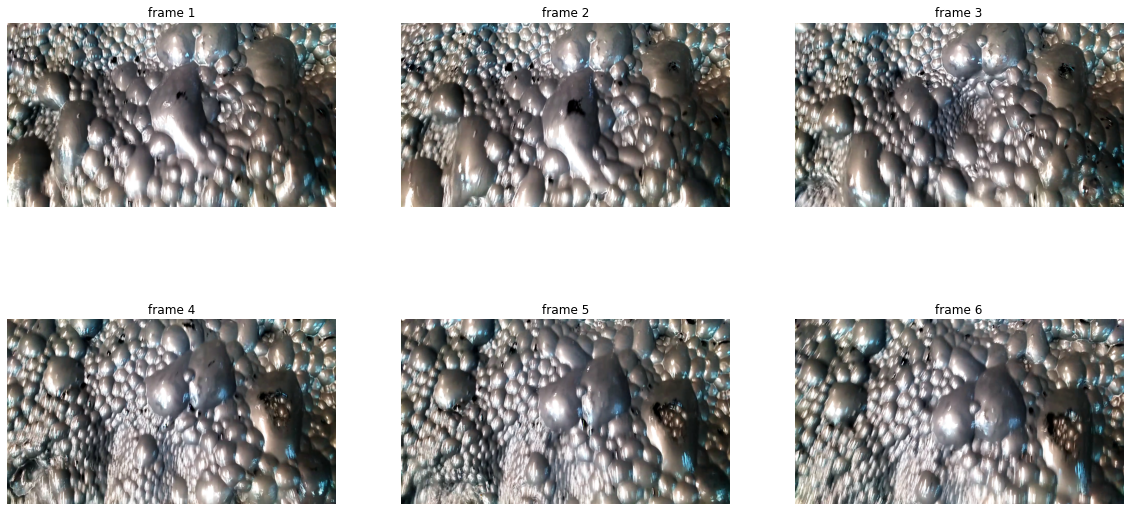

In [3]:
# getting frames from the second 7 to 7.5
cap.set(cv.CAP_PROP_POS_MSEC, 7500)
ret, frame = cap.read()
cap.set(cv.CAP_PROP_POS_MSEC, 7600)
ret, frame2 = cap.read()
cap.set(cv.CAP_PROP_POS_MSEC, 7700)
ret, frame3 = cap.read()
cap.set(cv.CAP_PROP_POS_MSEC, 8200)
ret, frame4 = cap.read()
cap.set(cv.CAP_PROP_POS_MSEC, 8300)
ret, frame5 = cap.read()
cap.set(cv.CAP_PROP_POS_MSEC, 8400)
ret, frame6 = cap.read()


# ploting the frames in a 2x2 grid
fig, ax = plt.subplots(2, 3, figsize=(20, 10))

# delete axis
for i in range(2):
    for j in range(3):
        ax[i, j].axis('off')


ax[0, 0].imshow(frame)
ax[0, 0].set_title('frame 1')
ax[0, 1].imshow(frame2)
ax[0, 1].set_title('frame 2')
ax[0, 2].imshow(frame3)
ax[0, 2].set_title('frame 3')
ax[1, 0].imshow(frame4)
ax[1, 0].set_title('frame 4')
ax[1, 1].imshow(frame5)
ax[1, 1].set_title('frame 5')
ax[1, 2].imshow(frame6)
ax[1, 2].set_title('frame 6')

plt.show()


Text(0.5, 1.0, 'mse: 52.842830946180555')

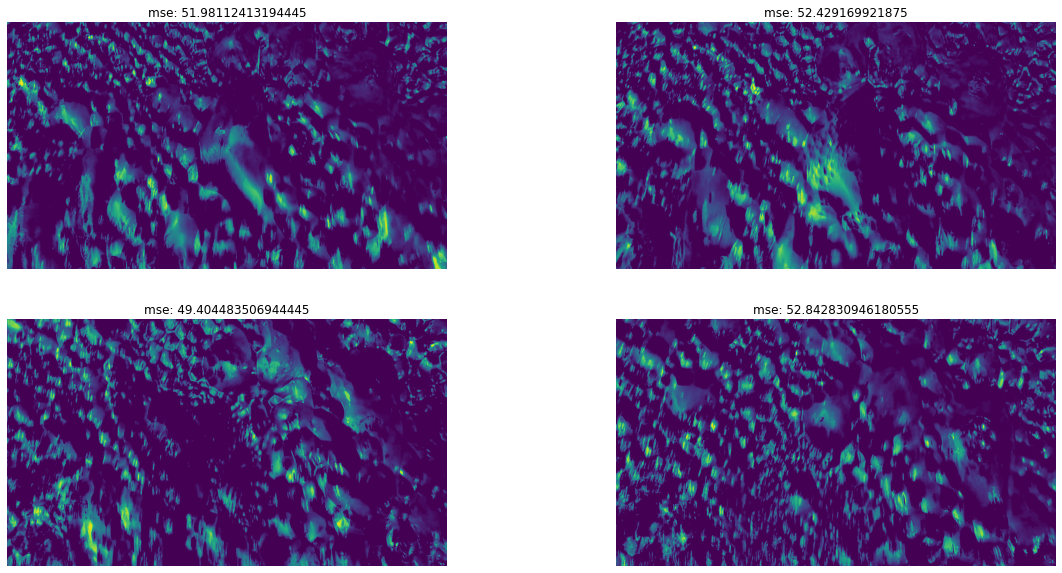

In [4]:
# converting the frames to grayscale
frame = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
frame2 = cv.cvtColor(frame2, cv.COLOR_BGR2GRAY)
frame3 = cv.cvtColor(frame3, cv.COLOR_BGR2GRAY)
frame4 = cv.cvtColor(frame4, cv.COLOR_BGR2GRAY)
frame5 = cv.cvtColor(frame5, cv.COLOR_BGR2GRAY)

def calculate_mse(img1, img2):
    h, w = img1.shape
    diff = cv.subtract(img1, img2)
    err = np.sum(diff**2)
    mse = err/(float(h*w))
    return mse, diff


# calculating the mean square error
mse1, diff1 = calculate_mse(frame, frame2)
mse2, diff2 = calculate_mse(frame2, frame3)
mse3, diff3 = calculate_mse(frame3, frame4)
mse4, diff4 = calculate_mse(frame4, frame5)

# ploting the mean square error
fig, ax = plt.subplots(2, 2, figsize=(20, 10))

# delete axis
for i in range(2):
    for j in range(2):
        ax[i, j].axis('off')

ax[0, 0].imshow(diff1)
ax[0, 0].set_title(f"mse: {mse1}")
ax[0, 1].imshow(diff2)
ax[0, 1].set_title(f"mse: {mse2}")
ax[1, 0].imshow(diff3)
ax[1, 0].set_title(f"mse: {mse3}")
ax[1, 1].imshow(diff4)
ax[1, 1].set_title(f"mse: {mse4}")


Text(0.5, 1.0, 'ssim: 0.22683652654810718')

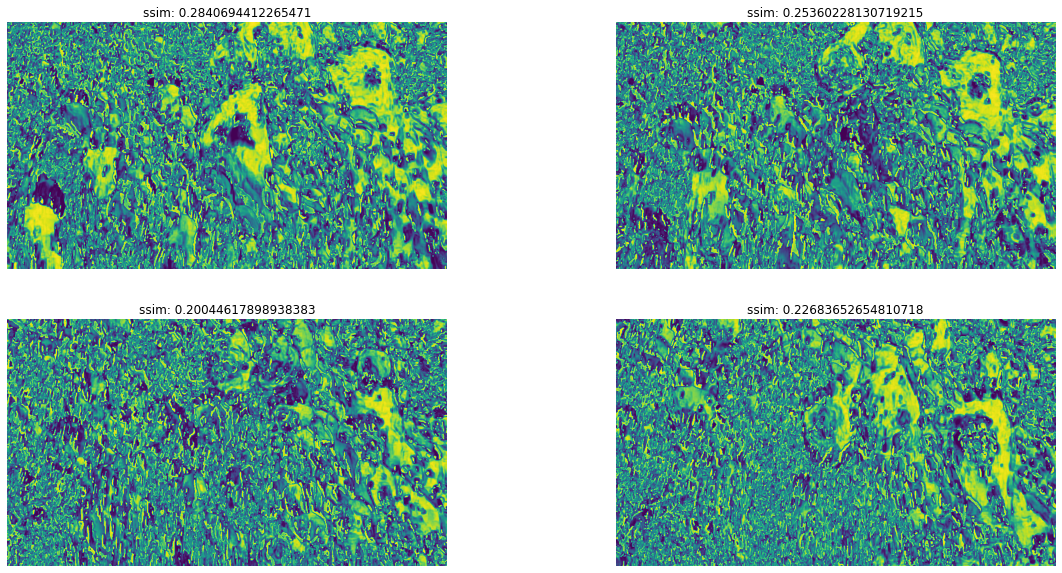

In [5]:
from skimage.metrics import structural_similarity as compare_ssim

# calculating the structural similarity
(score1, diff1) = compare_ssim(frame, frame2, full=True)
diff1 = (diff1 * 255).astype("uint8")
(score2, diff2) = compare_ssim(frame2, frame3, full=True)
diff2 = (diff2 * 255).astype("uint8")
(score3, diff3) = compare_ssim(frame3, frame4, full=True)
diff3 = (diff3 * 255).astype("uint8")
(score4, diff4) = compare_ssim(frame4, frame5, full=True)
diff4 = (diff4 * 255).astype("uint8")

# ploting the structural similarity
fig, ax = plt.subplots(2, 2, figsize=(20, 10))

# delete axis
for i in range(2):
    for j in range(2):
        ax[i, j].axis('off')

ax[0, 0].imshow(diff1)
ax[0, 0].set_title(f"ssim: {score1}")
ax[0, 1].imshow(diff2)
ax[0, 1].set_title(f"ssim: {score2}")
ax[1, 0].imshow(diff3)
ax[1, 0].set_title(f"ssim: {score3}")
ax[1, 1].imshow(diff4)
ax[1, 1].set_title(f"ssim: {score4}")



#  Froth Stability from a video

## The main function to calculate the average intensity values

In [6]:
def applied_method(cap,frames_to_take = cap.get(cv.CAP_PROP_FRAME_COUNT)):
    
    # getting the frame rate
    fps = cap.get(cv.CAP_PROP_FPS)
    # getting the frame count
    frame_count = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
    
    # getting two consecutive frames from the video and calculating the mean square error and the structural similarity
    mse_list = []
    mse_diff_list = []
    ssim_list = []
    ssim_diff_list = []
    for i in range(frame_count):
        if i == 0:
            ret, frame = cap.read()
            ret, frame2 = cap.read()
        else:
            # get frame by number
            cap.set(cv.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            cap.set(cv.CAP_PROP_POS_FRAMES, i+1)
            ret, frame2 = cap.read()
        if ret:
            frame = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
            frame2 = cv.cvtColor(frame2, cv.COLOR_BGR2GRAY)

            mse, diff = calculate_mse(frame, frame2)
            mse_list.append(mse)
            mse_diff_list.append(diff)
            (score, diff) = compare_ssim(frame, frame2, full=True)
            ssim_list.append(score)
            ssim_diff_list.append(diff)

    return mse_list, mse_diff_list, ssim_list, ssim_diff_list


In [7]:
# get the index of the biggest difference between the frames
def get_index_of_biggest_difference(avg_intensity_frames):
    # getting the index of the biggest difference between the frames
    index_of_biggest_difference = []
    for i in range(len(avg_intensity_frames)-1):
        index_of_biggest_difference.append(abs(avg_intensity_frames[i] - avg_intensity_frames[i+1]))

    index_of_biggest_difference = np.argmax(index_of_biggest_difference)
    return index_of_biggest_difference

## Function to plot the values

In [8]:
def plot_results(avg_intensity_frames):
    # ploting the average intensity of the average frames
    if len(avg_intensity_frames) >= 100:
        for i in range(0, len(avg_intensity_frames), 100):
            plt.figure(figsize=(30, 10))
            plt.xticks(np.arange(0, len(avg_intensity_frames[i:i+100]), 1))
            plt.plot(avg_intensity_frames[i:i+100])
            plt.show()
    else:
        plt.figure(figsize=(20, 10))
        plt.xticks(np.arange(0, len(avg_intensity_frames), 1))
        plt.plot(avg_intensity_frames)
        plt.show()

## Fuction to visualize the frames

In [9]:
def plot_diff_frames(frames,index,index2):
    # plot 2x5 subplots 
    fig, axs = plt.subplots(2, len(frames[index]), figsize=(30, 10))
    # axis off
    for ax in axs.flat:
        ax.axis('off')
    for i in range(len(frames[index])):
        axs[0, i].imshow(frames[index][i])
        axs[1, i].imshow(frames[index2][i])
        axs[0, i].set_title('frame ' + str(i))
        axs[1, i].set_title('frame ' + str(i))
    plt.show()

# Statistical readings

In [10]:
def get_statistics(l):
    # Box plot of the average intensity of the average frames
    plt.figure(figsize=(20, 10))
    plt.boxplot(l)
    # value of the median
    plt.axhline(np.median(l), color='r', linestyle='dashed', linewidth=1)
    # Value of the first quartile
    plt.axhline(np.percentile(l, 25), color='r', linestyle='dashed', linewidth=1)
    # Value of the third quartile
    plt.axhline(np.percentile(l, 75), color='r', linestyle='dashed', linewidth=1)
    plt.title("Box plot")
    plt.show()

    # distribution of the average intensity of the average frames
    plt.figure(figsize=(20, 10))
    plt.title("Values distribution")
    plt.hist(l, bins=50)
    plt.show()

    # data frame with the statistics
    df = pd.DataFrame({"mean": [np.mean(l)], "median": [np.median(l)], "first quartile": [np.percentile(l, 25)], "third quartile": [np.percentile(l, 75)], "upper whisker": [np.percentile(l, 75) + 1.5*(np.percentile(l, 75) - np.percentile(l, 25))], "lower whisker": [np.percentile(l, 25) - 1.5*(np.percentile(l, 75) - np.percentile(l, 25))], "variance": [np.var(l)], "standard deviation": [np.std(l)]})

    # render dataframe on notebook
    return df
    


In [11]:
def get_outlier(l_avg_int):
    # all values above the upper whisker or under the lower whisker are considered outliers
    outliers = []
    upper_whisker = np.percentile(l_avg_int, 75) + 1.5*(np.percentile(l_avg_int, 75) - np.percentile(l_avg_int, 25))
    lower_whisker = np.percentile(l_avg_int, 25) - 1.5*(np.percentile(l_avg_int, 75) - np.percentile(l_avg_int, 25))
    for i in range(len(l_avg_int)):
        if l_avg_int[i] > upper_whisker or l_avg_int[i] < lower_whisker:
            outliers.append(i)
    return outliers


# Results for the first video

### The results are presented in plots, each plot represents the fluctuation of the average intensity, x-axis is the frames and y-axis is the average intensity.


### First we read the video and it caracteristics (fps, number of frames), also we ask the user for the number of frames to be used to calculate the average image

In [12]:
%%time

# reading the video
cap = cv.VideoCapture('rl4_pb17-4.mp4')

# getting the frame rate
fps = cap.get(cv.CAP_PROP_FPS)

print(f"video fps: {fps}")

# getting the frame count
frame_count = int(cap.get(cv.CAP_PROP_FRAME_COUNT))

# applying the method to the video
mse_values1, mse_diff1, ssim_values1, ssim_diff1 = applied_method(cap)


video fps: 29.703158414733778
CPU times: total: 7min 45s
Wall time: 4min 57s


In [13]:
frame_count

938

In [14]:
len(mse_values1),len(ssim_values1)

(937, 937)

### Plot the results
the result are a list of average intensity values, each value is calculated from a average image of a different number of frames (from the user), the firs value is the average intensity value of the n first frames, the second value is from the next n frames and so on. 
the intresting parts of this plots to be looking at are the sudden changes in the average intensity values, this sudden changes are the result of the collapse of bubbles.
To interpret the plot we need to compare the current value with the previous one and see the diffrence.

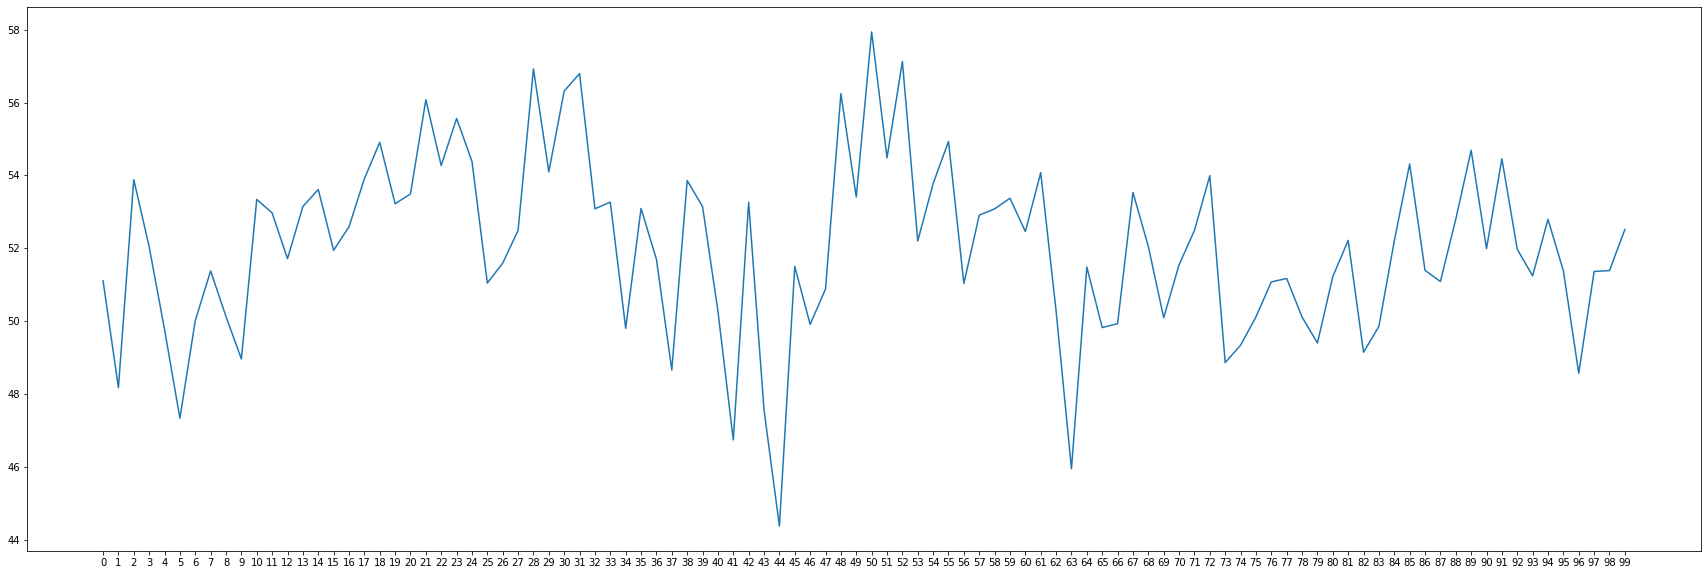

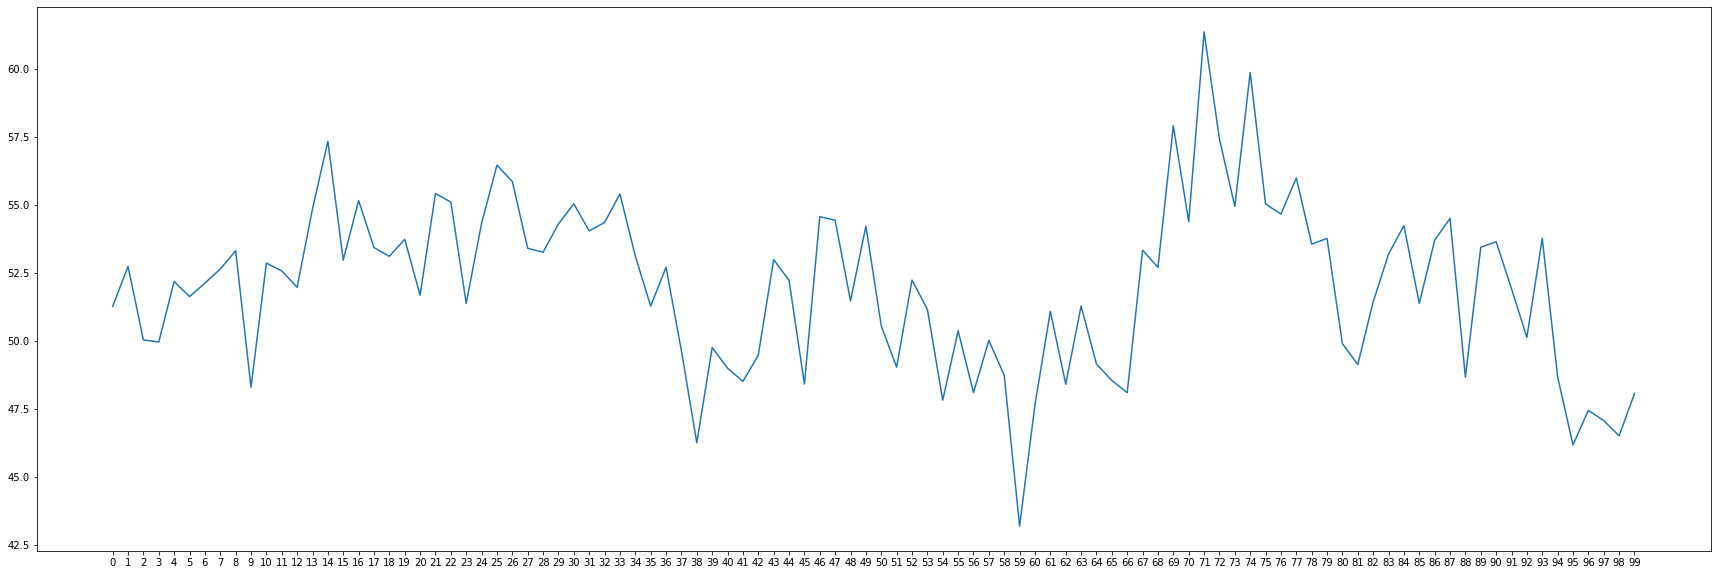

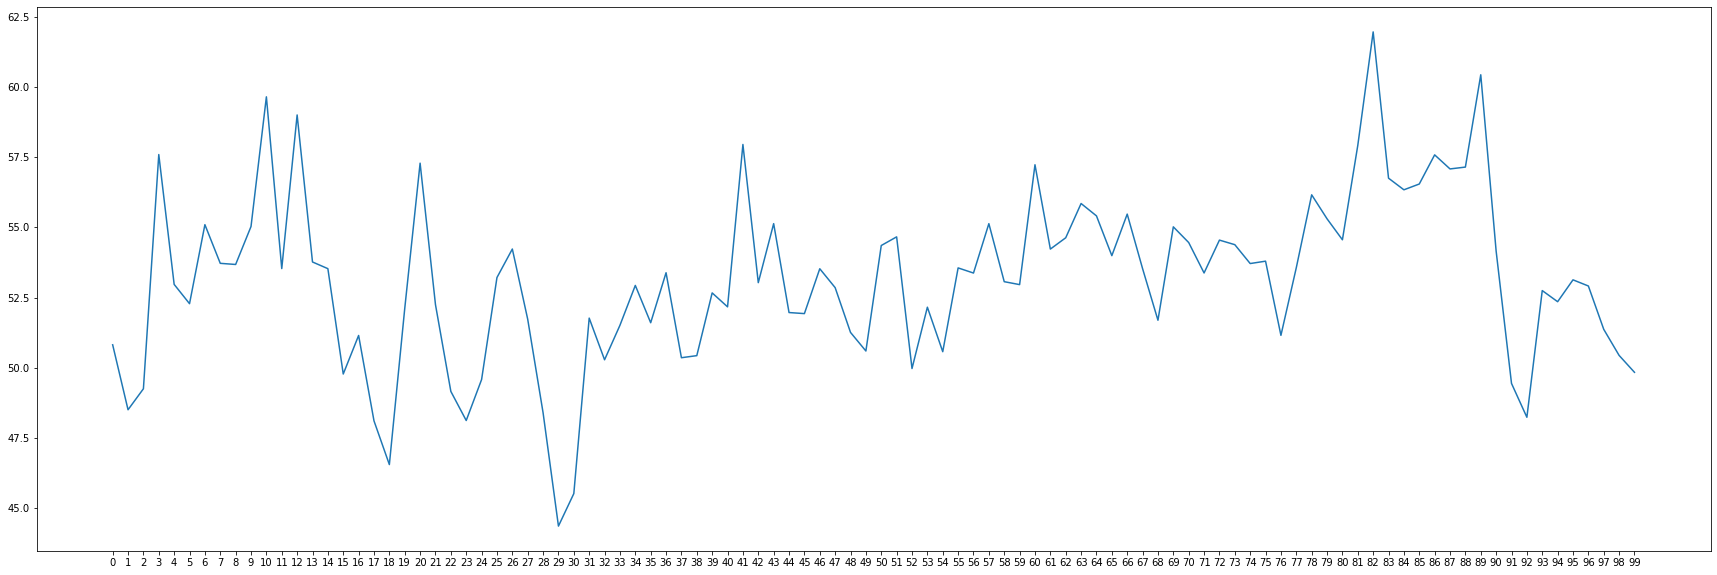

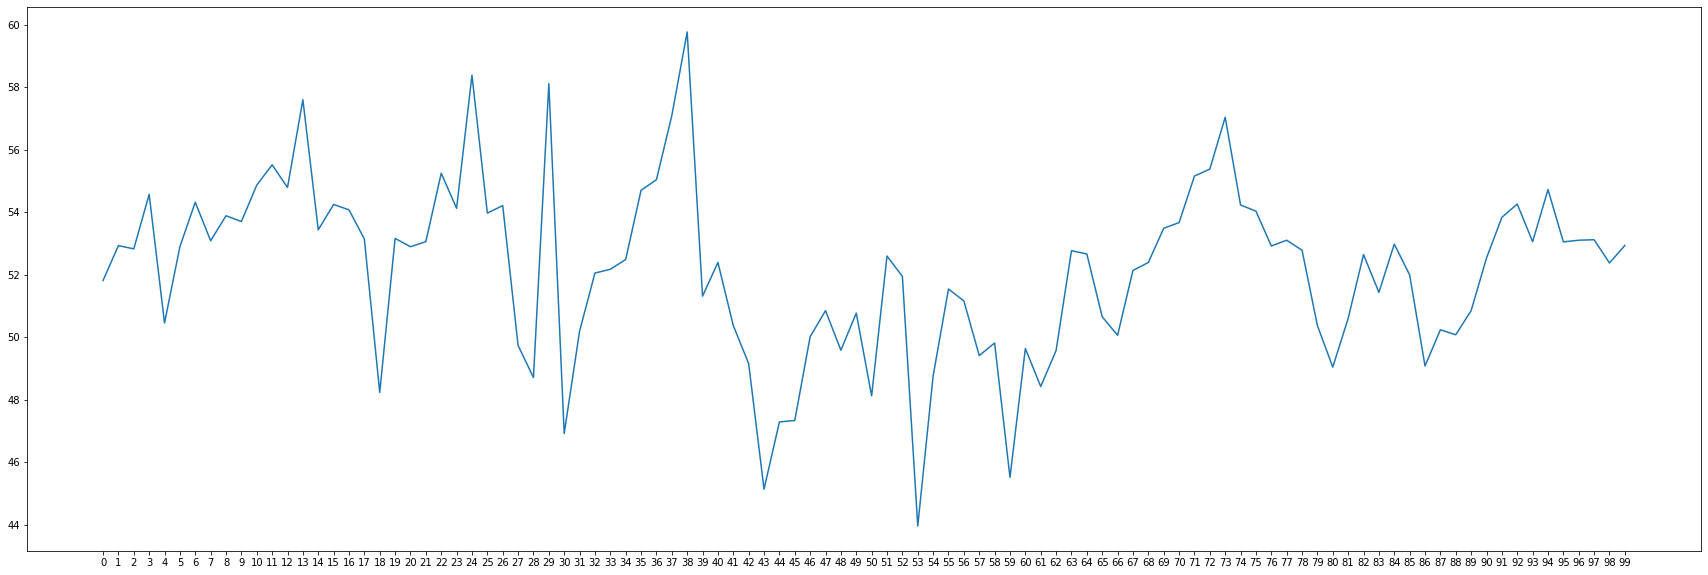

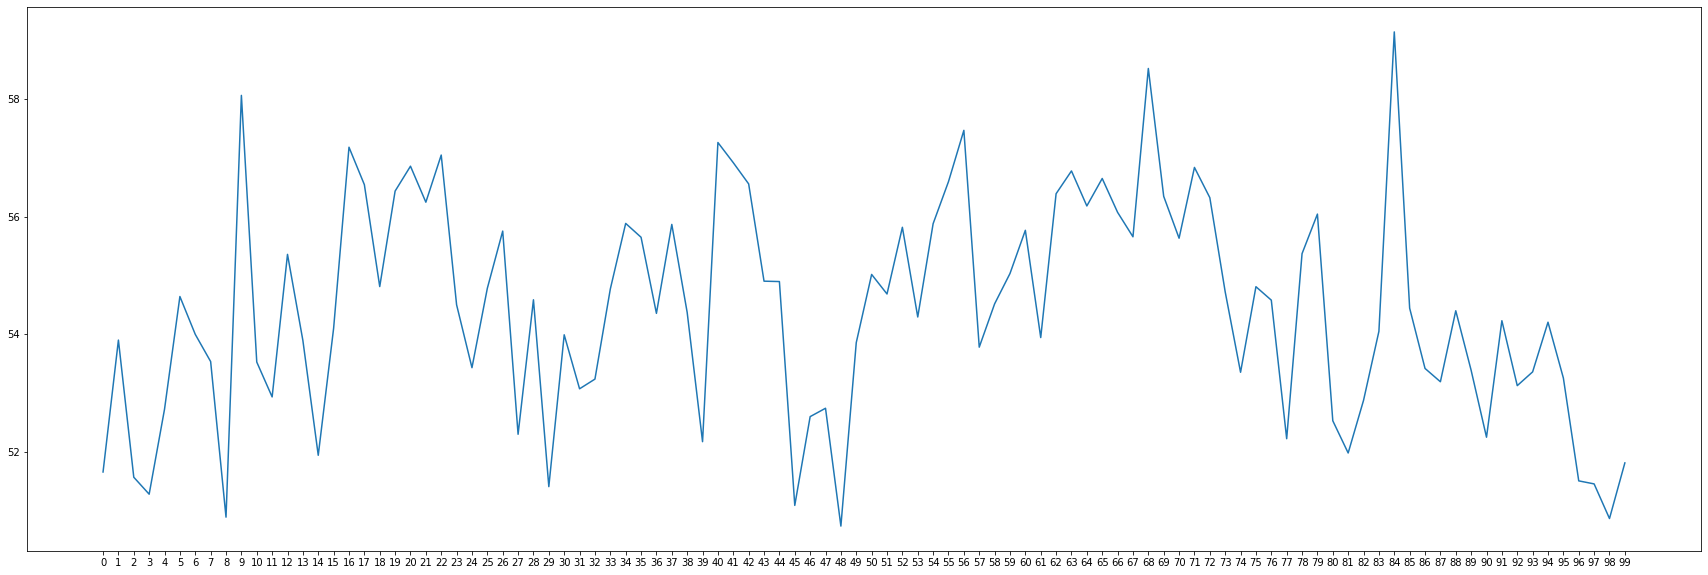

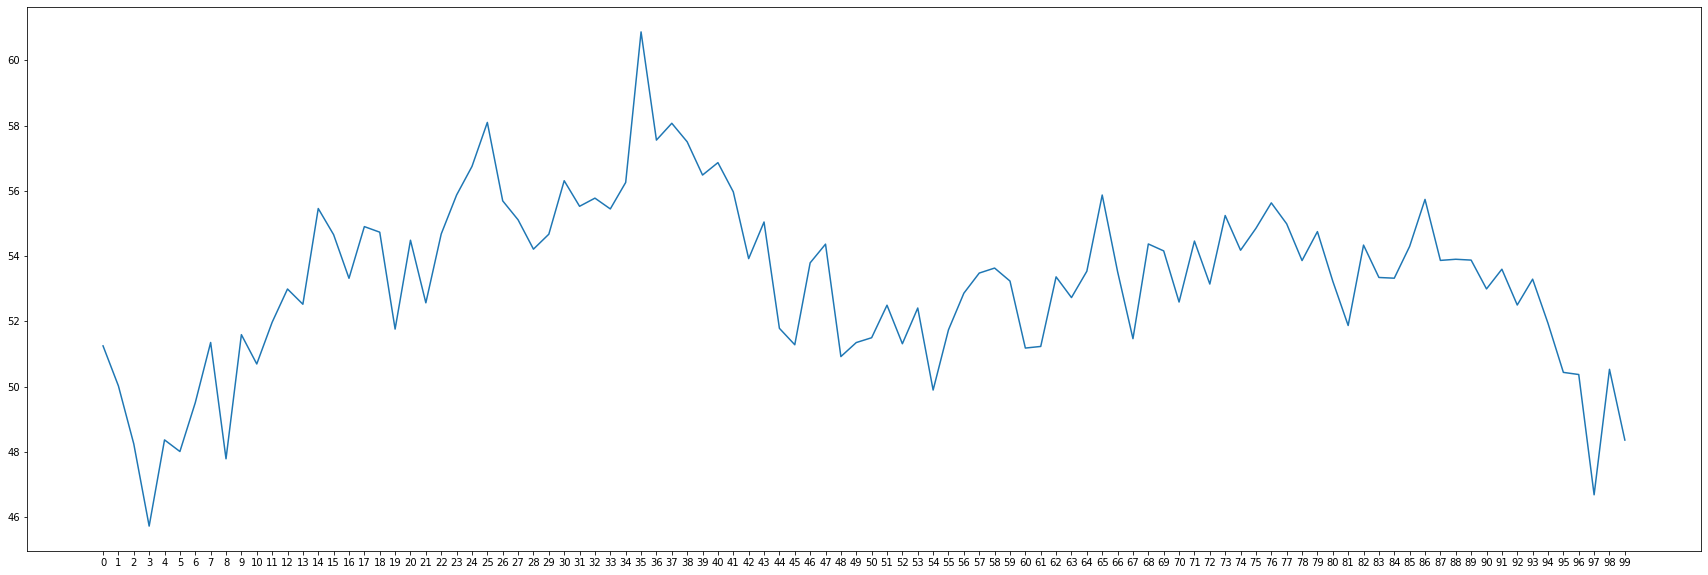

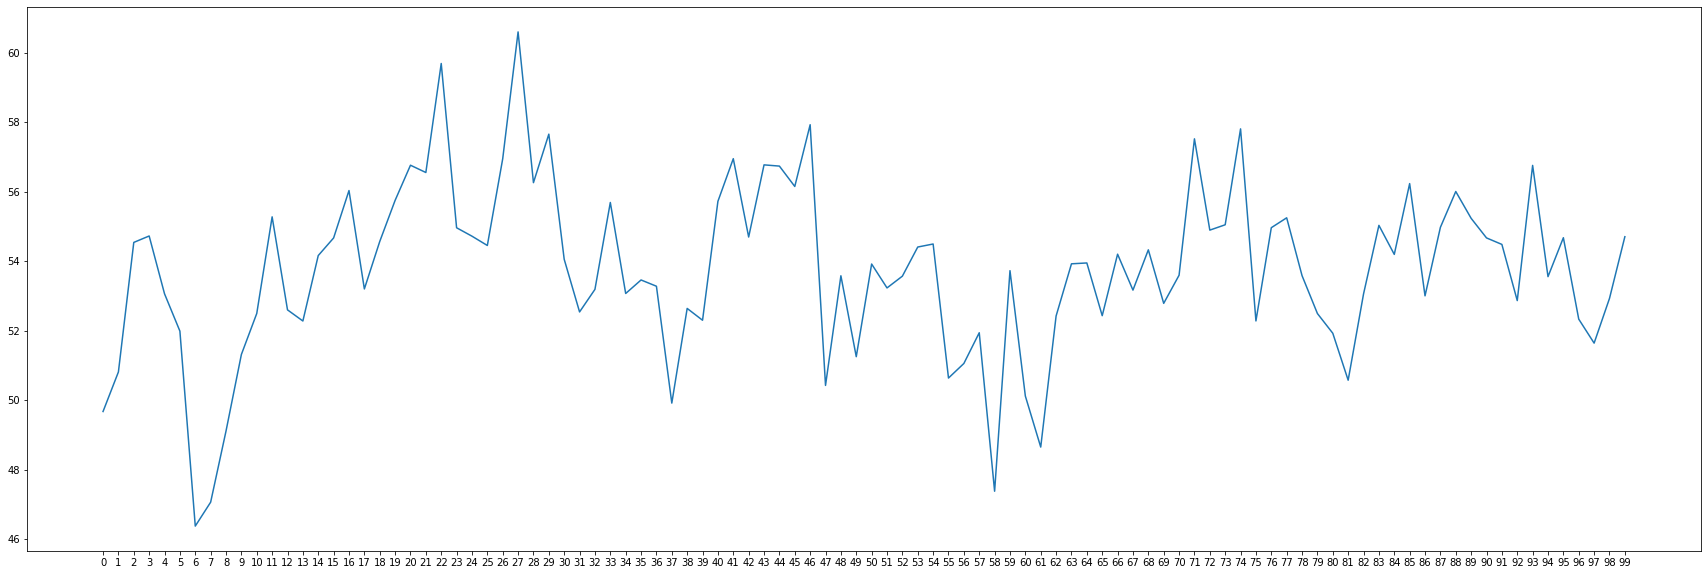

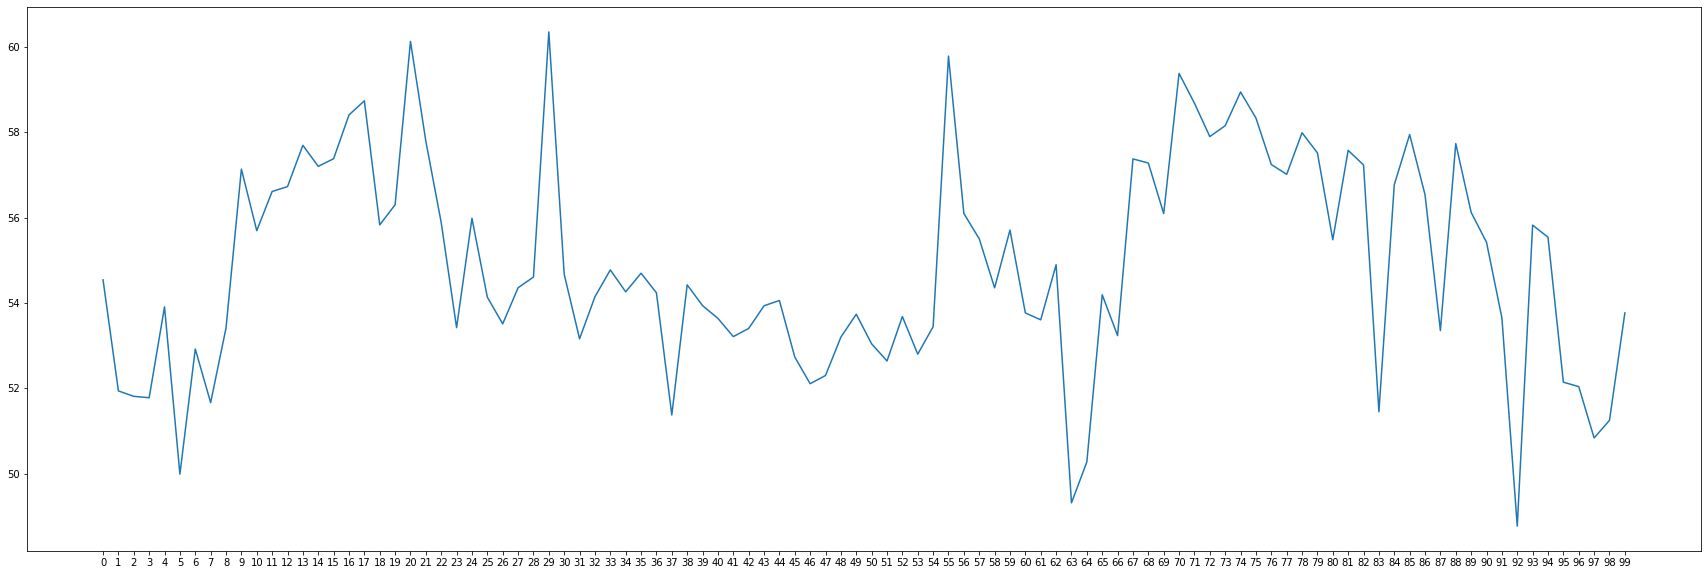

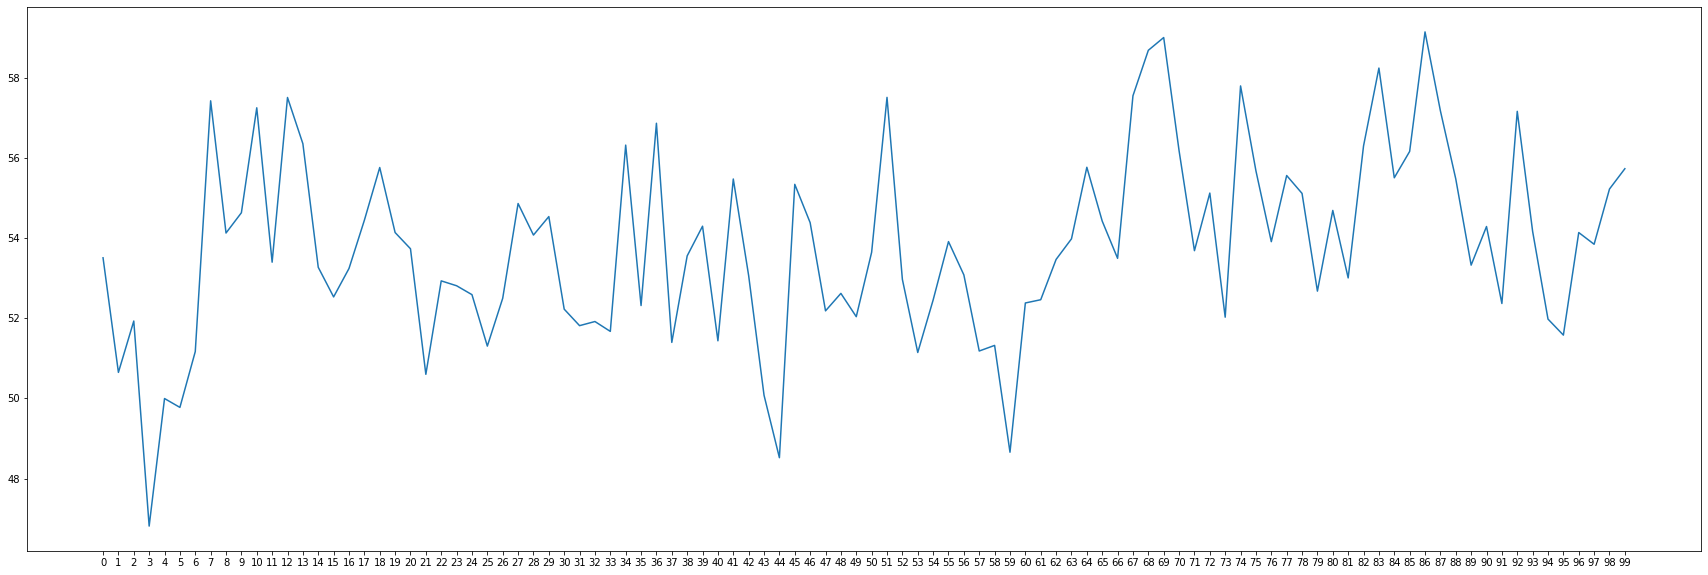

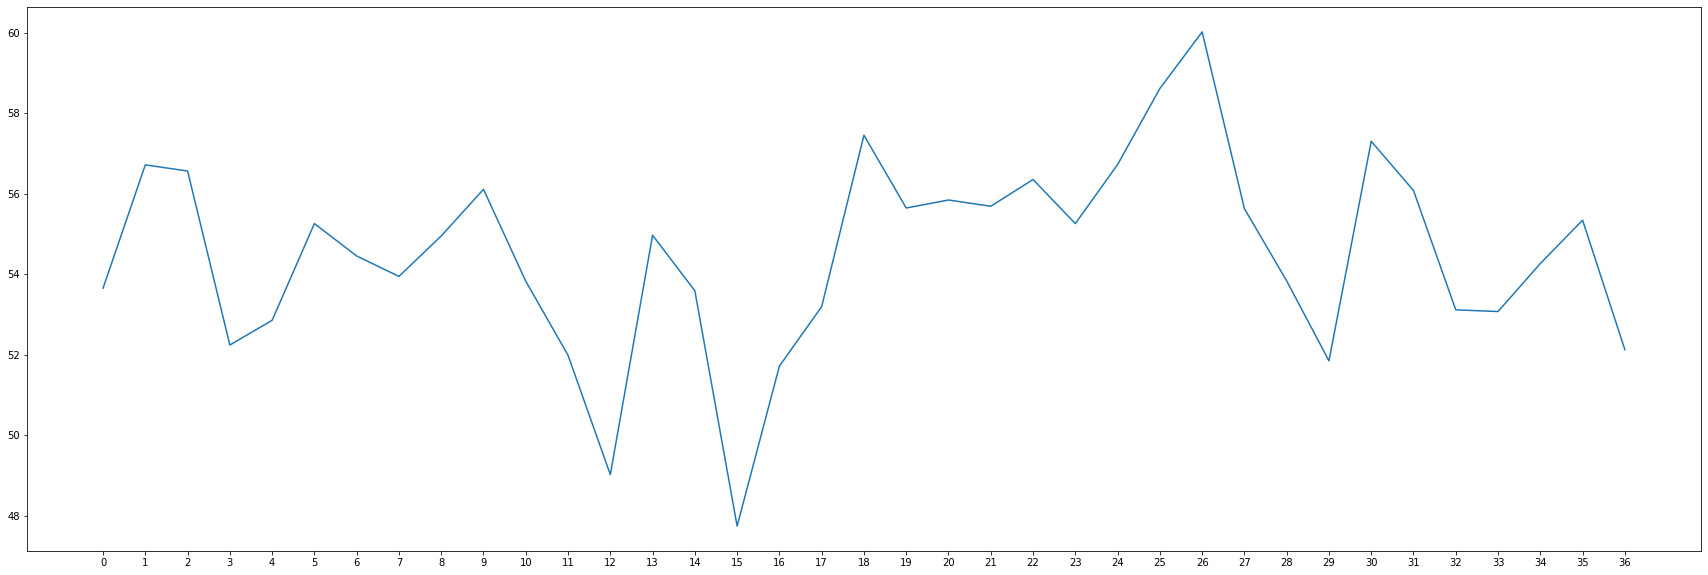

In [15]:
# ploting the average intensity of the average frames
plot_results(mse_values1)

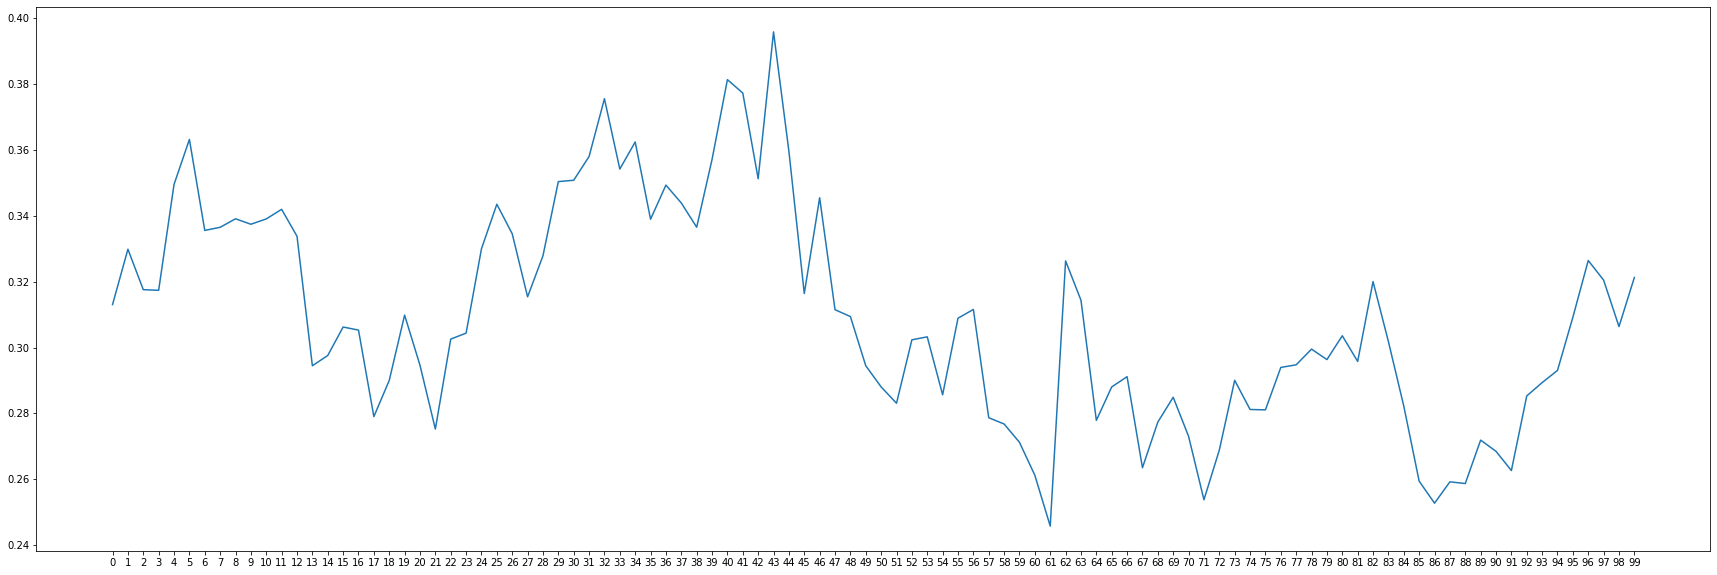

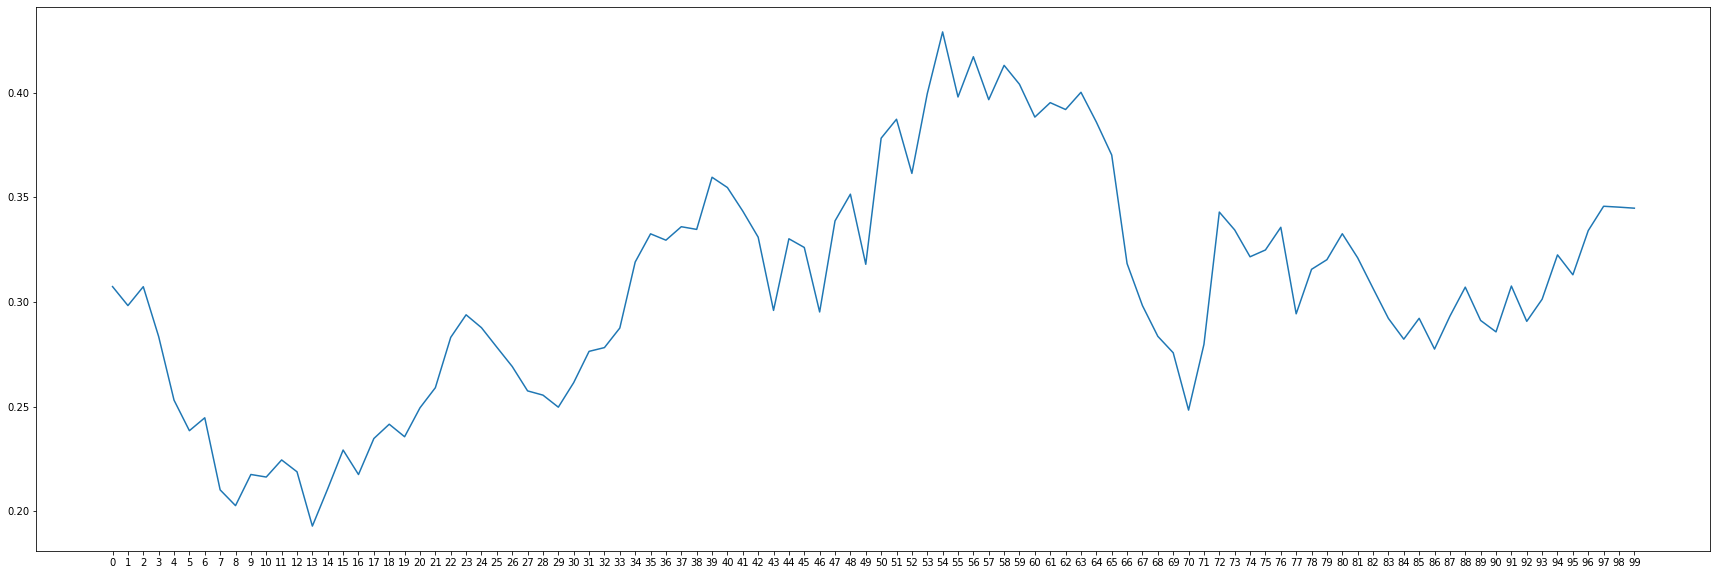

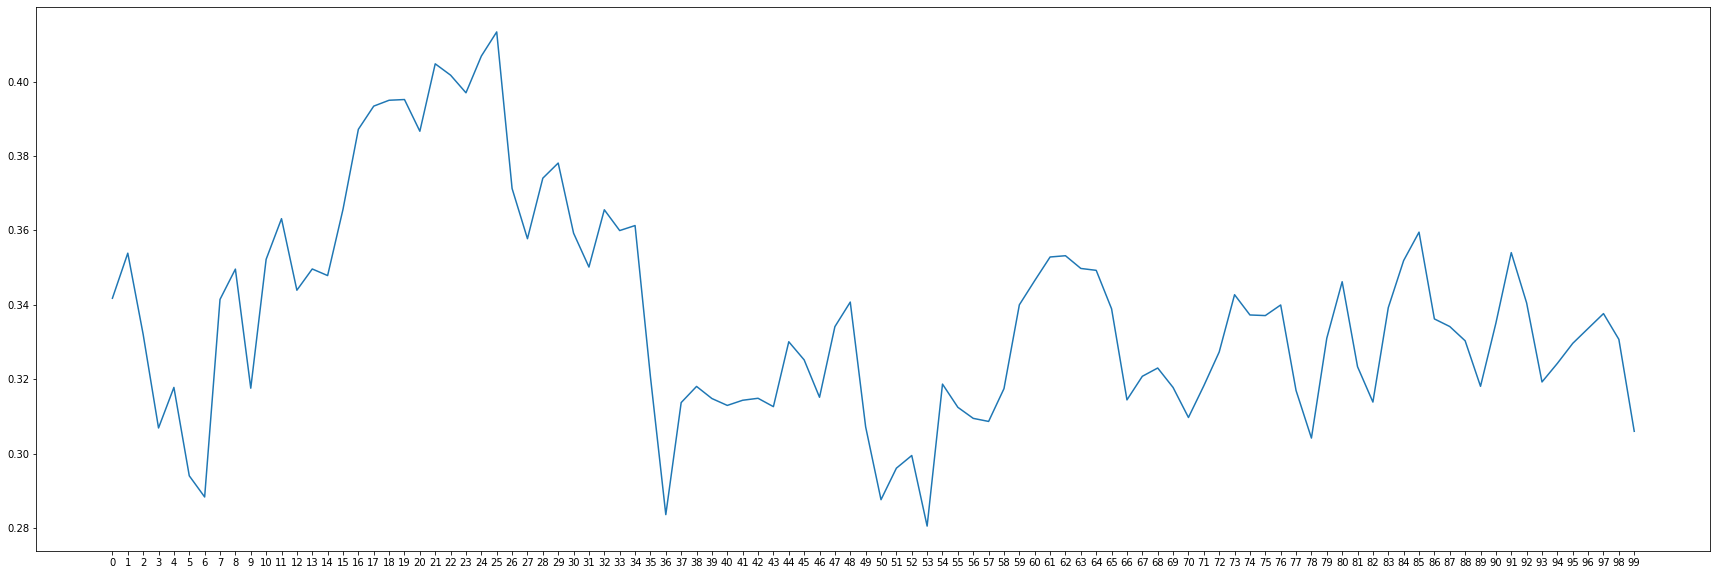

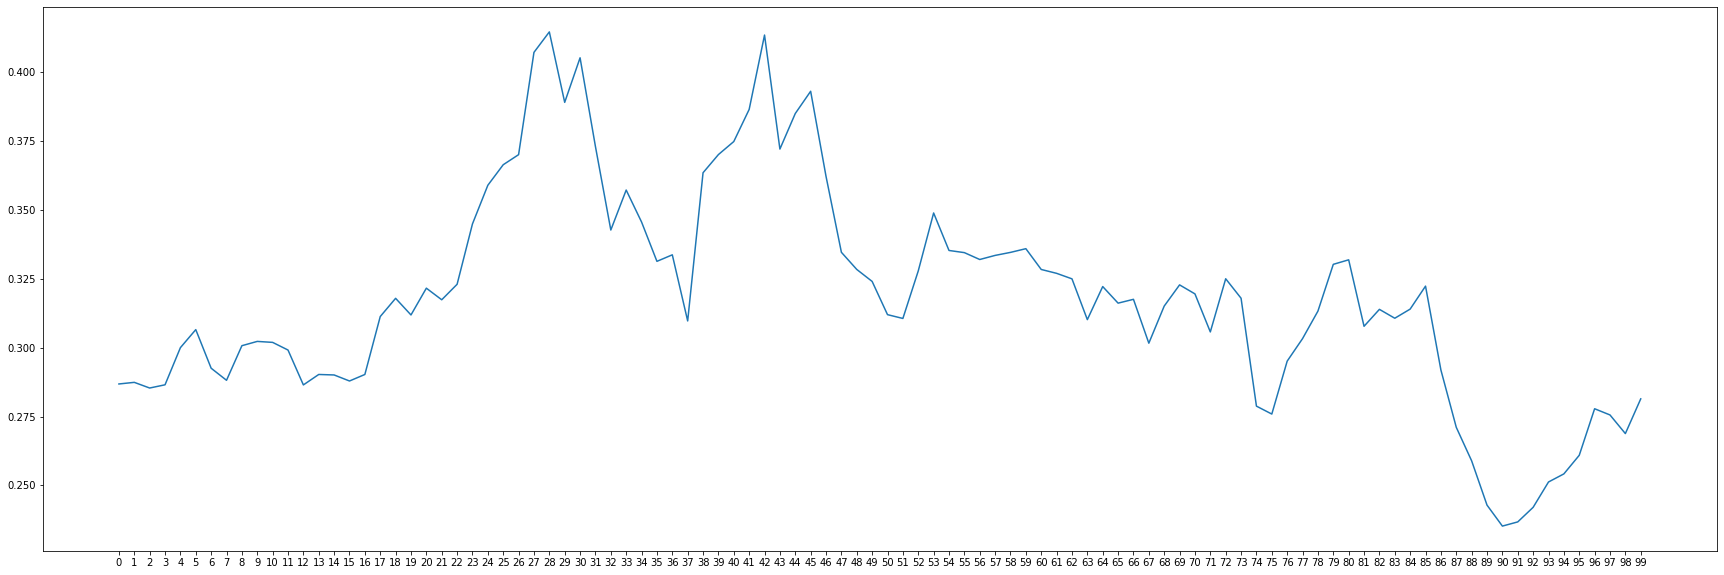

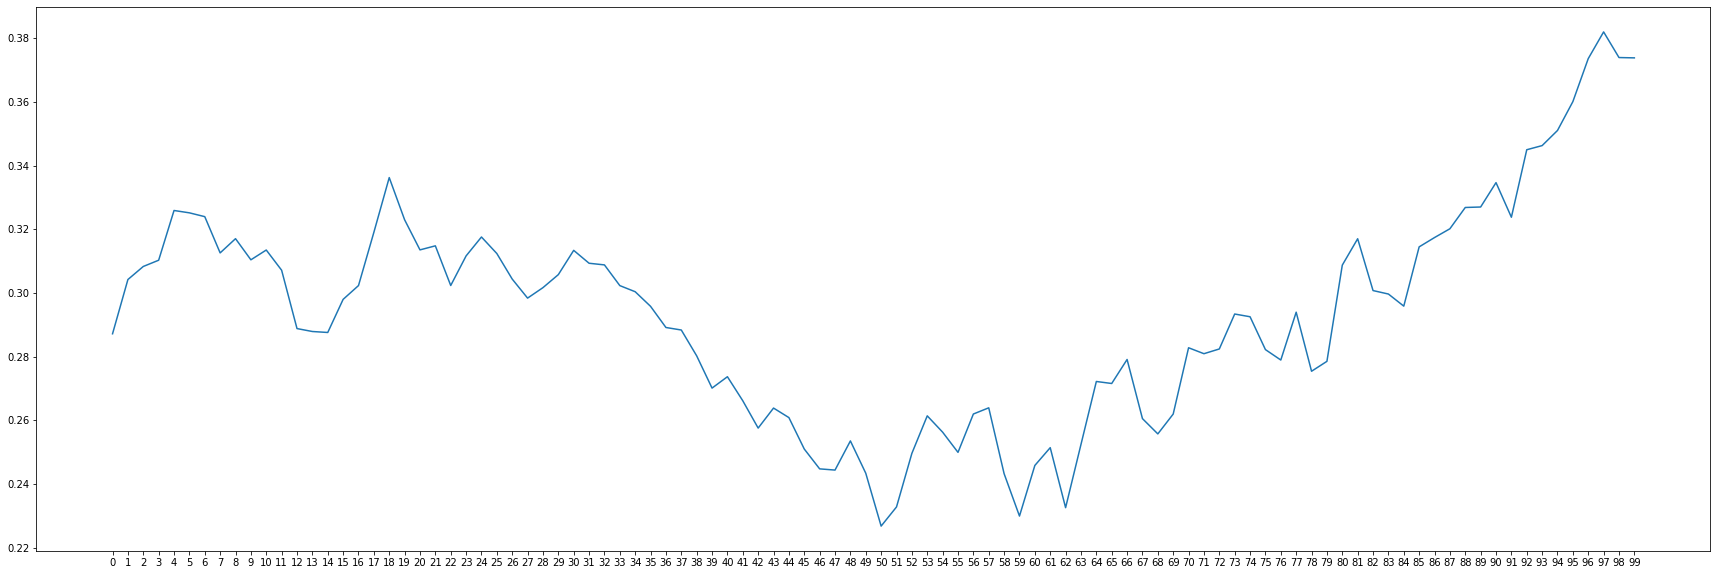

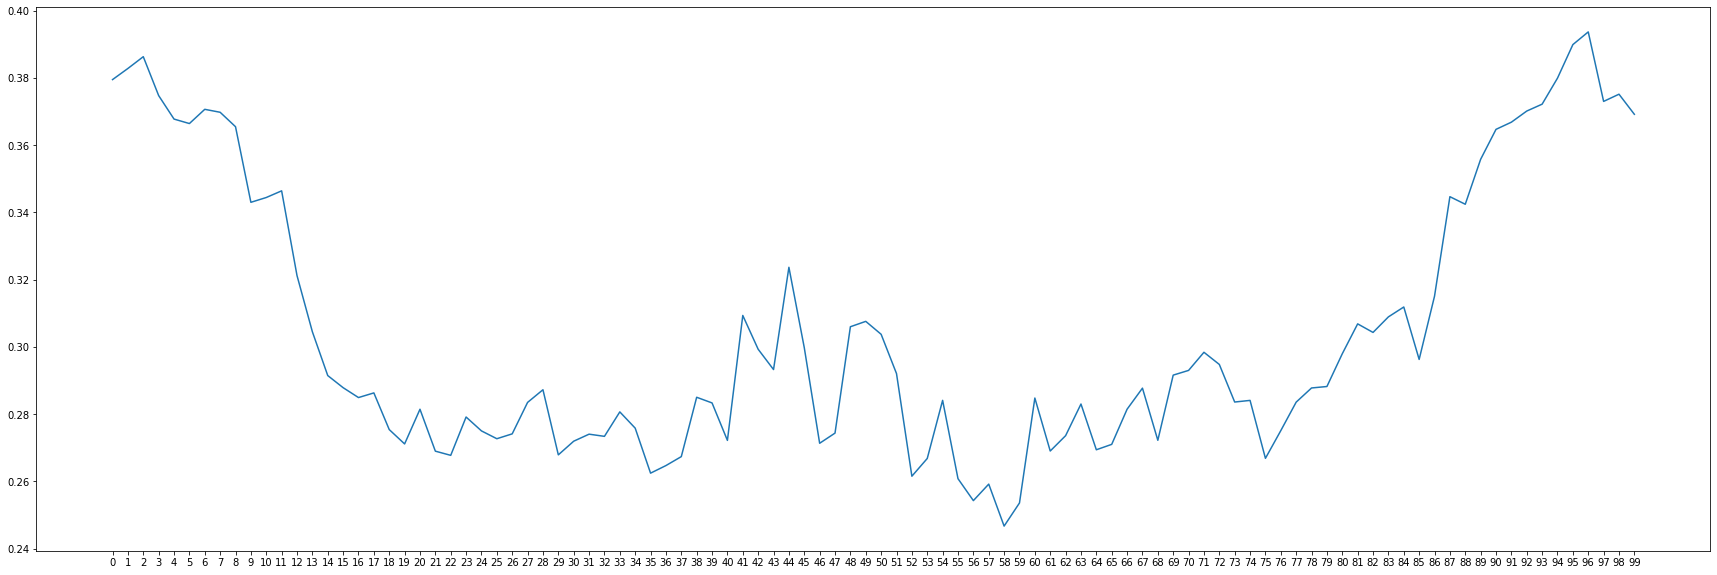

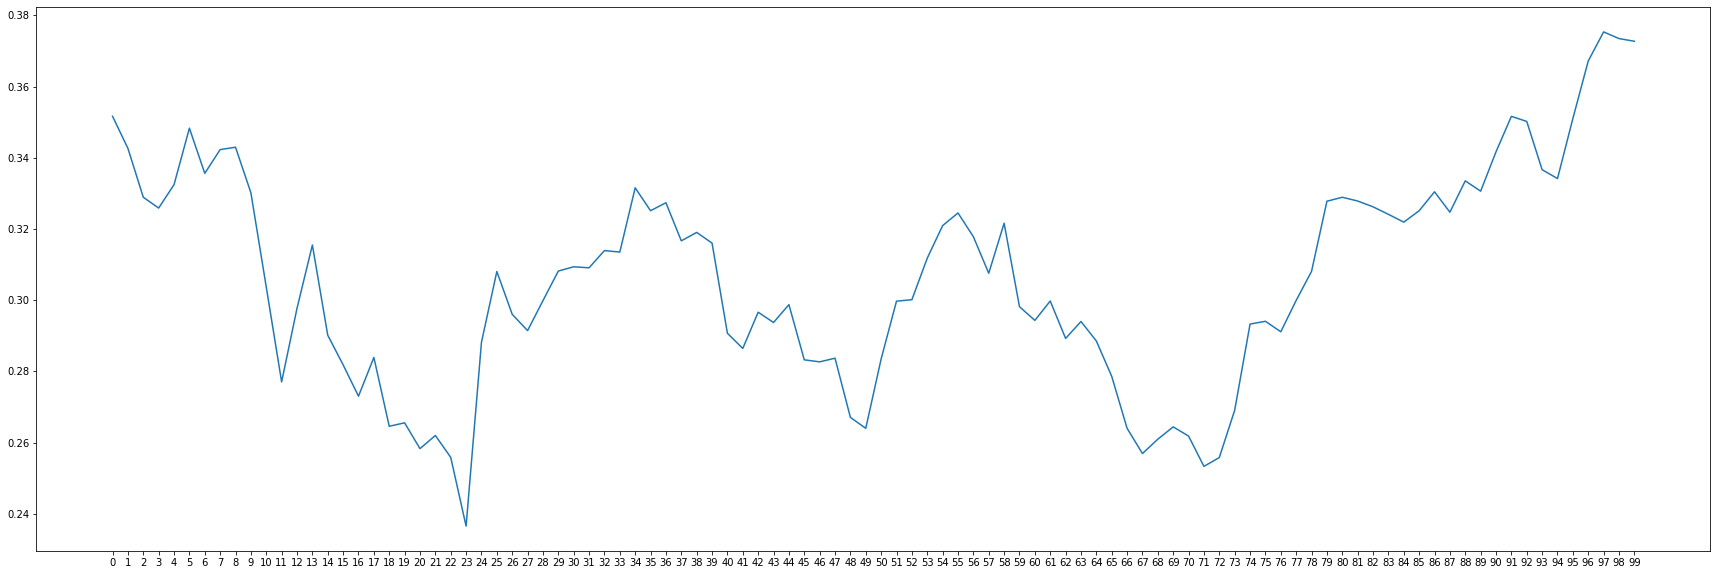

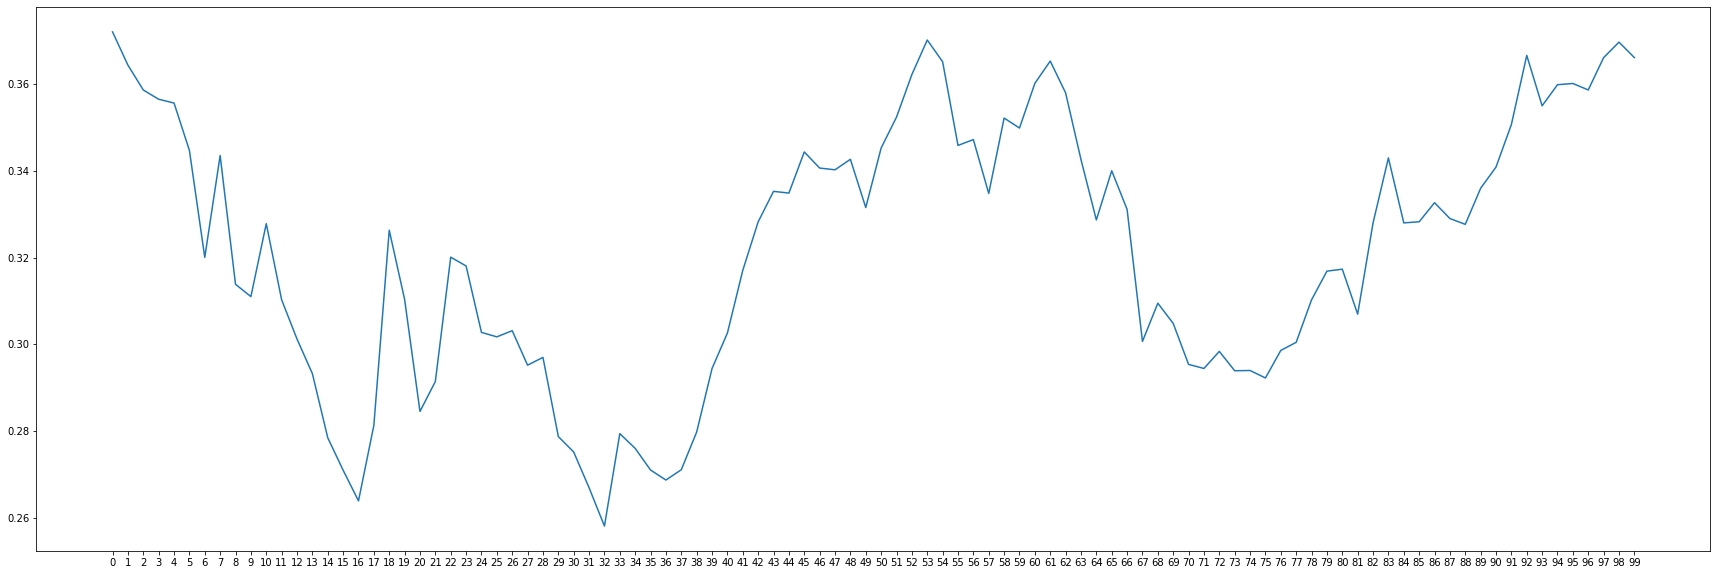

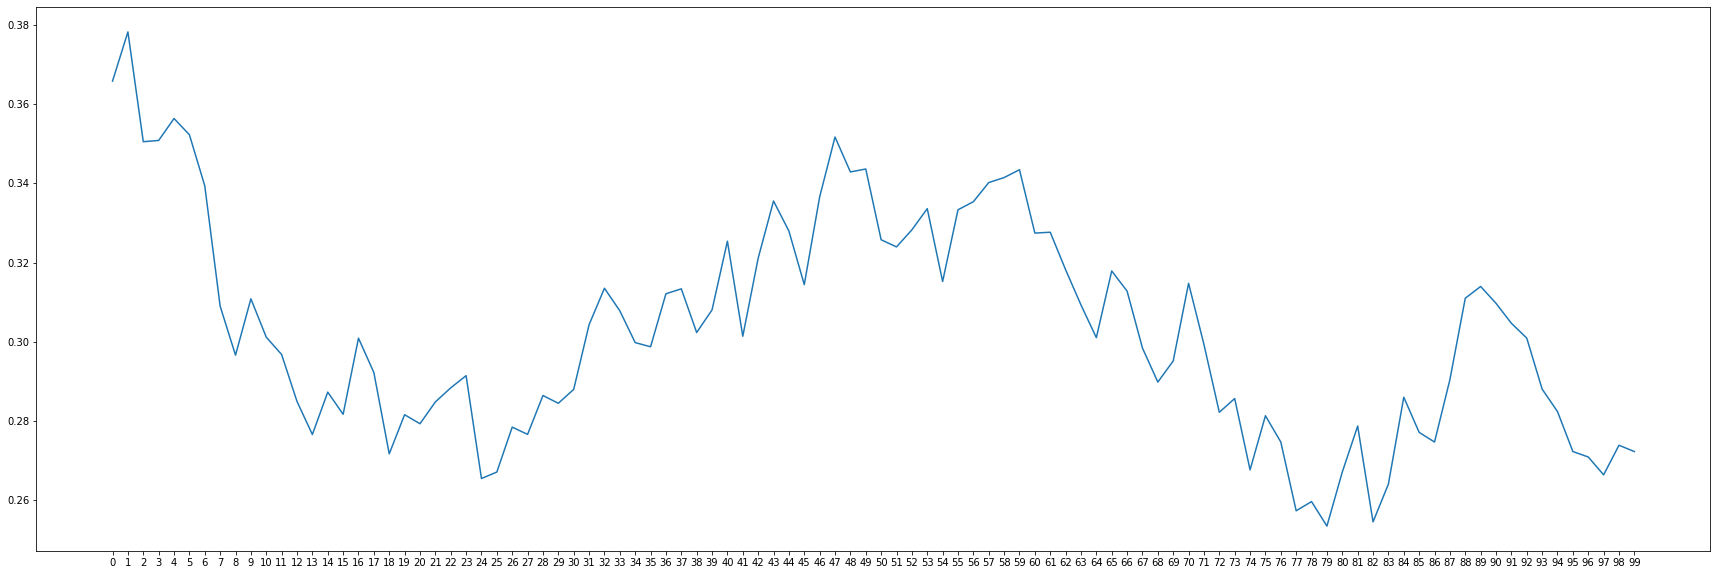

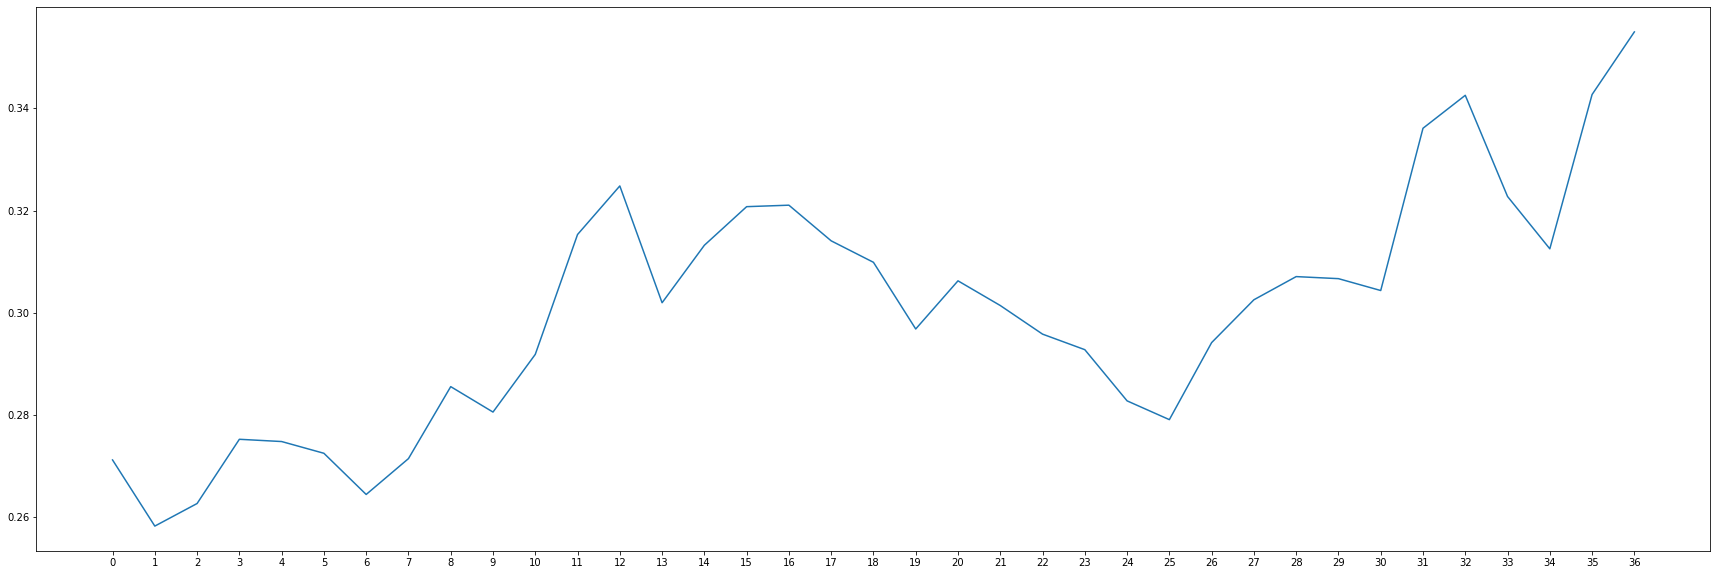

In [16]:
plot_results(ssim_values1)

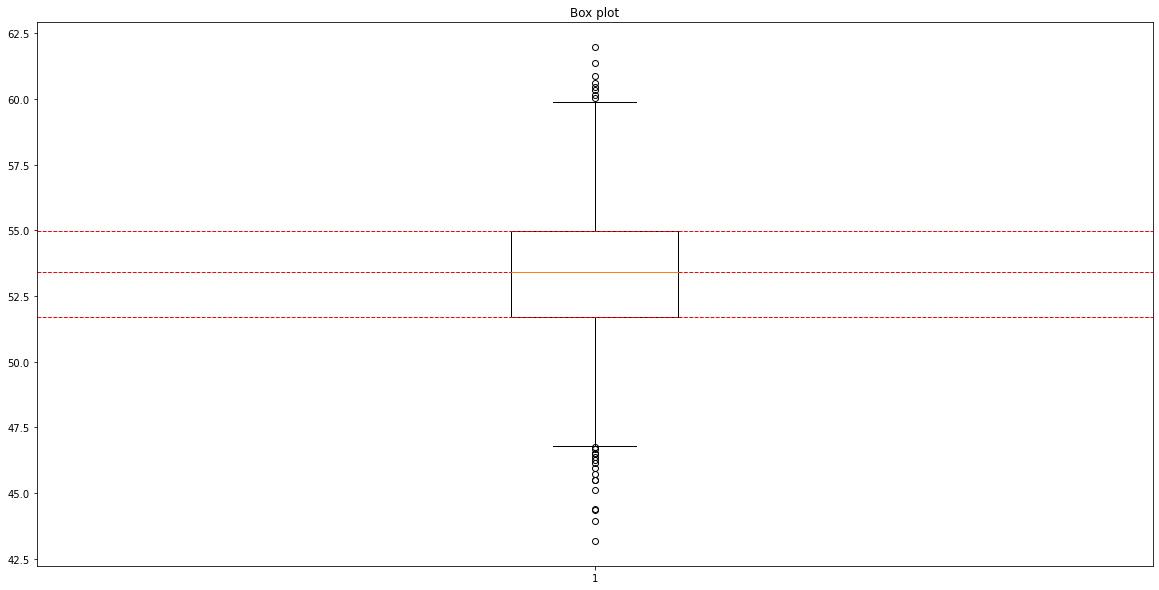

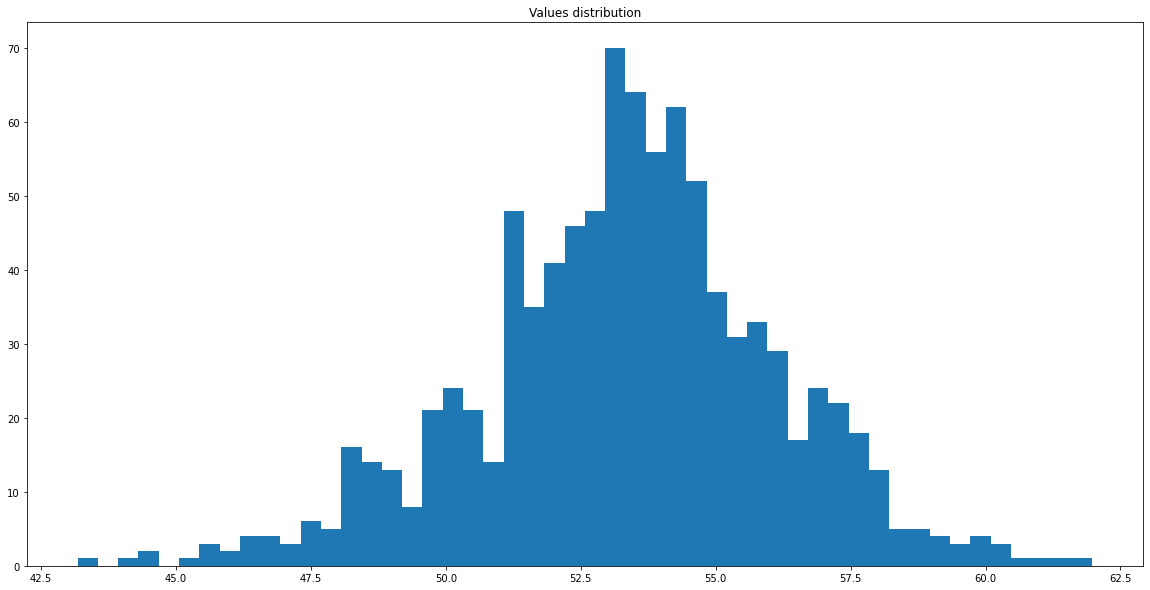

,mean,median,first quartile,third quartile,upper whisker,lower whisker,variance,standard deviation
0,53.330159,53.422612,51.715295,54.988634,59.898642,46.805287,7.647006,2.765322


In [17]:
get_statistics(mse_values1)

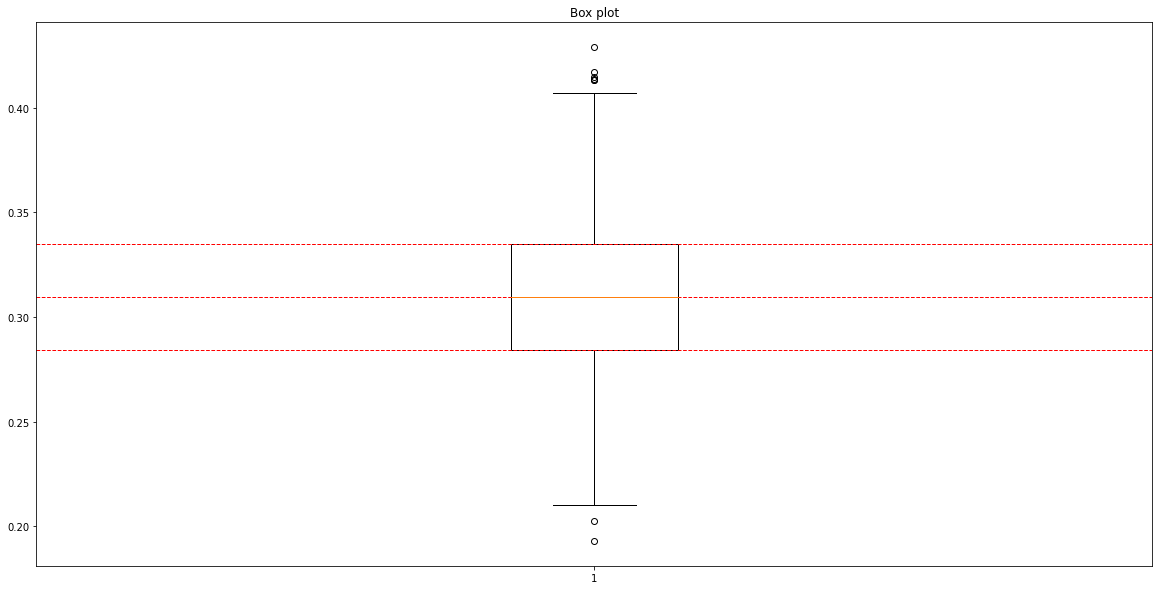

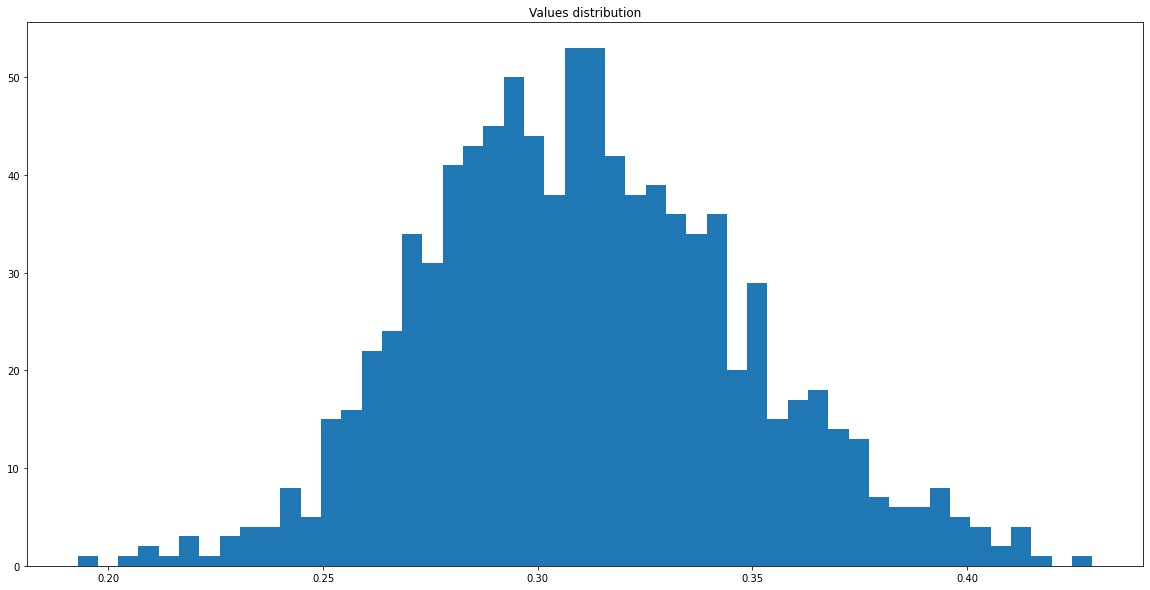

,mean,median,first quartile,third quartile,upper whisker,lower whisker,variance,standard deviation
0,0.310826,0.309325,0.284122,0.334837,0.41091,0.208049,0.001412,0.037574


In [19]:
get_statistics(ssim_values1)

# Results for the second video

### The results are presented in plots, each plot represents the fluctuation of the average intensity, x-axis is the frames and y-axis is the average intensity.


Same as the first video, we are looking for the sudden changes in the average intensity values. resulting in peeks in the plot.

In [21]:
%%time

cap2 = cv.VideoCapture('rl4_pb8-7.mp4')

# getting the frame rate
fps2 = cap2.get(cv.CAP_PROP_FPS)

print(f"video fps: {fps2}")

# getting the frame count
frame_count2 = int(cap2.get(cv.CAP_PROP_FRAME_COUNT))

print(f"video frame count: {frame_count2}")

# applying the method to the video
mse_values2, mse_diff2, ssim_values2, ssim_diff2 = applied_method(cap2)


video fps: 29.95603334971612
video frame count: 898
CPU times: total: 10min 29s
Wall time: 6min 7s


For this video, The fluctuations are smaller than the first video, and that's because the bubbles are smaller and the velocity is lower. so we can say that the froth in this video is more stable than the first one.

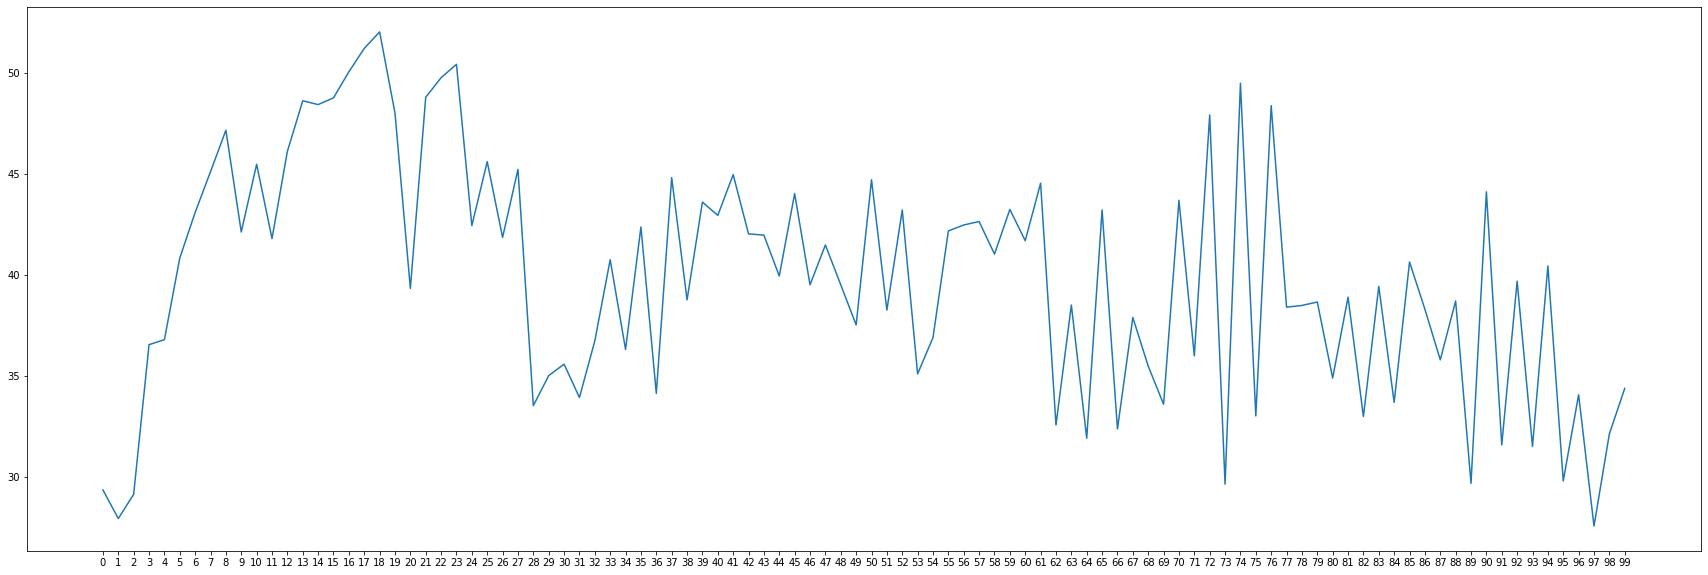

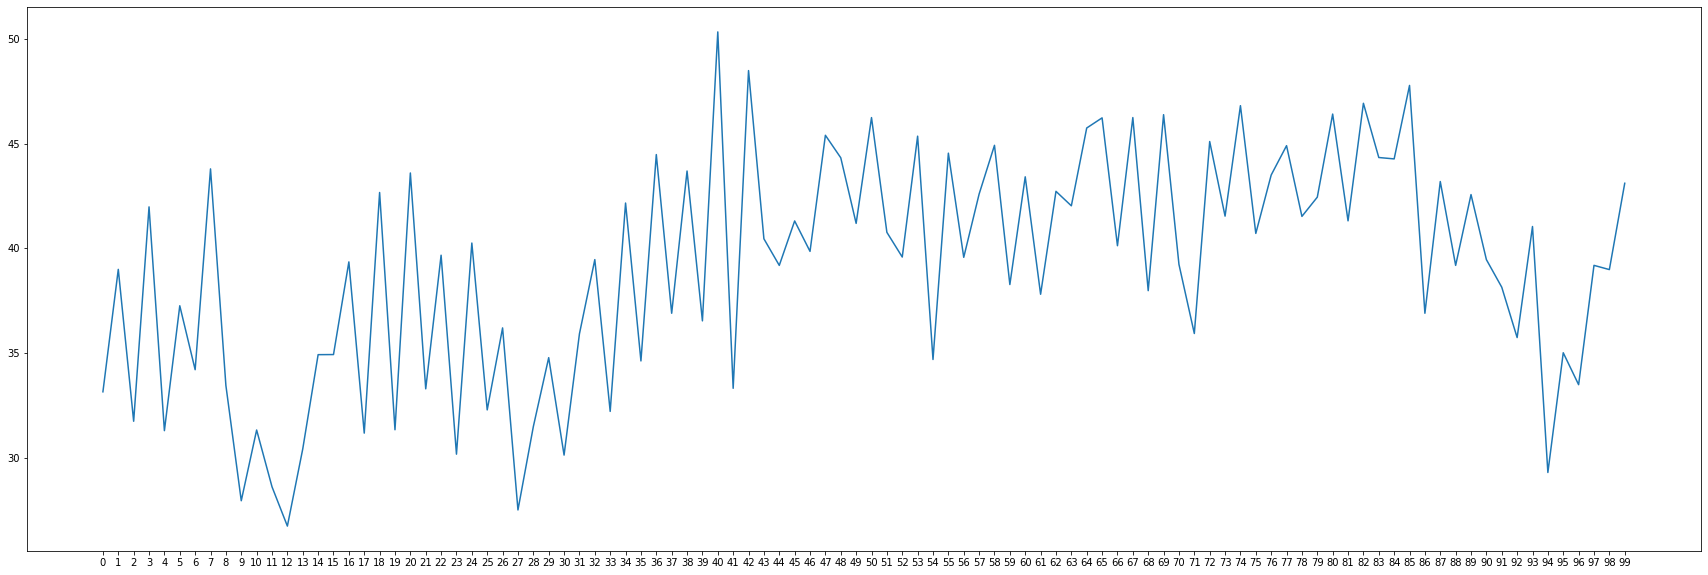

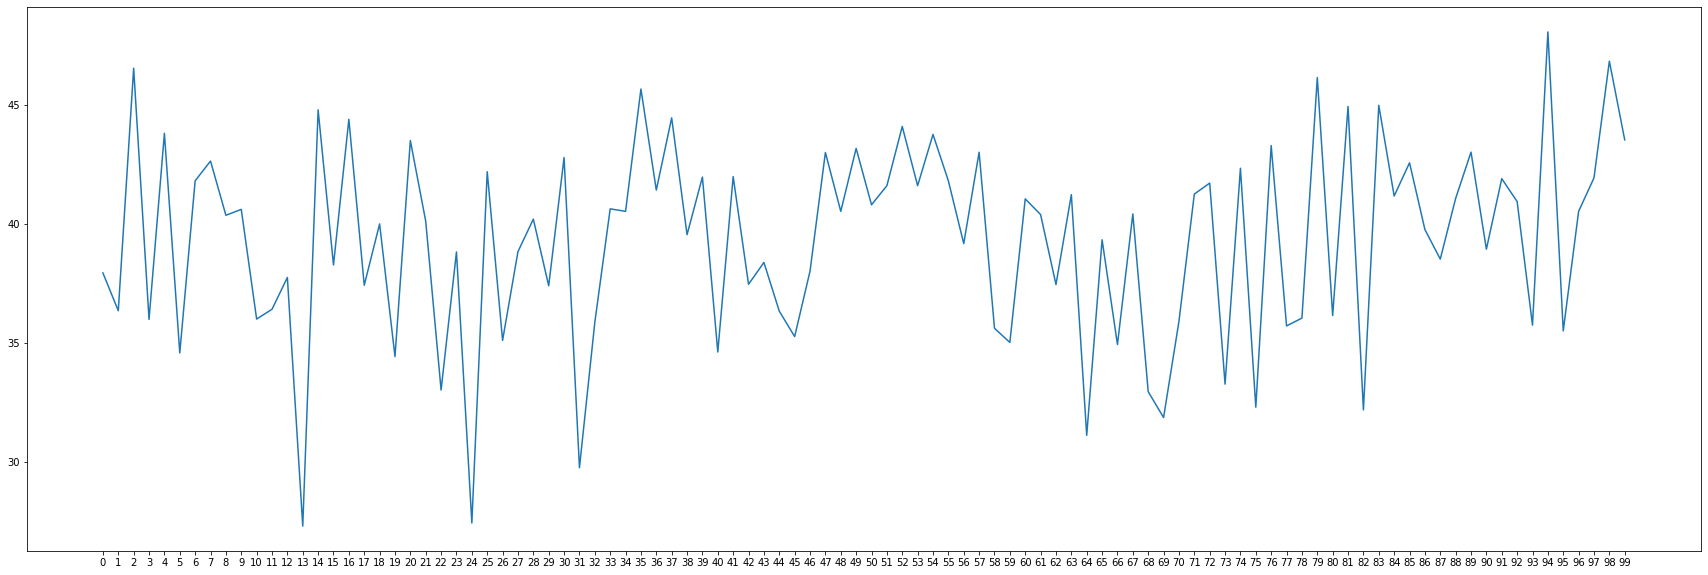

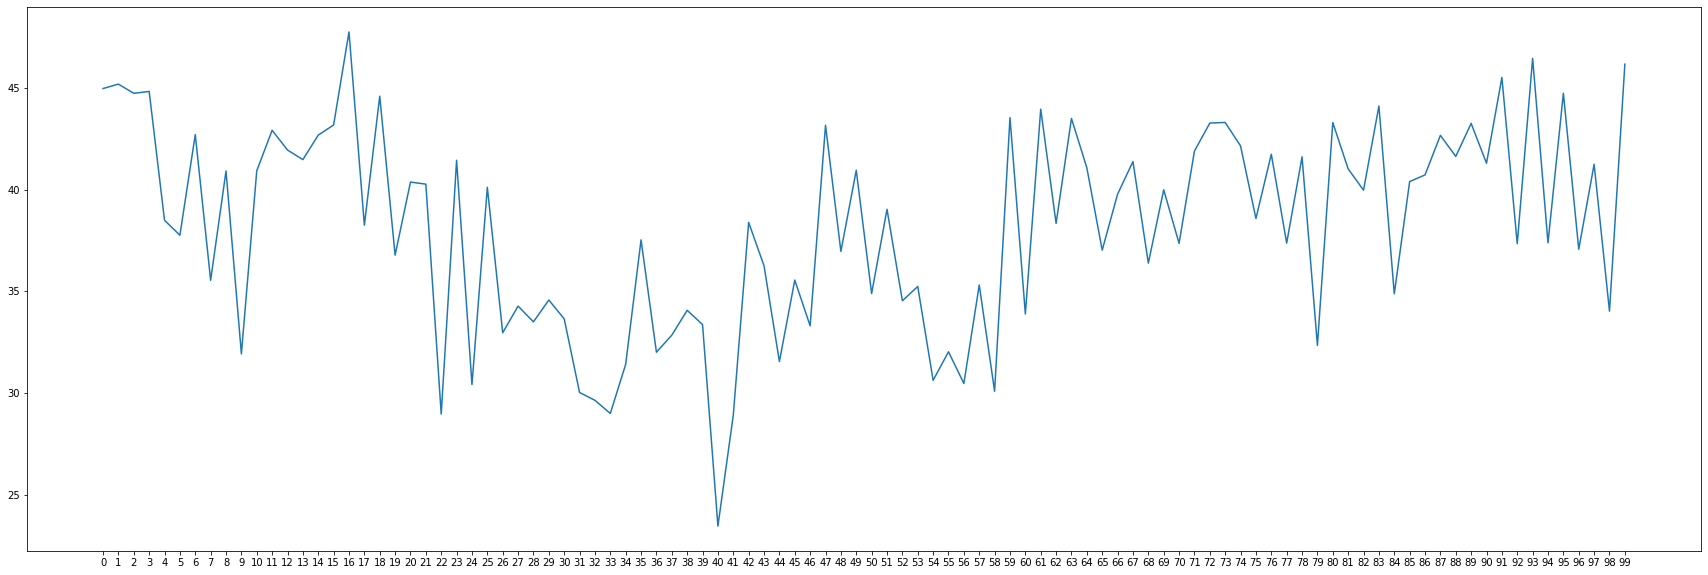

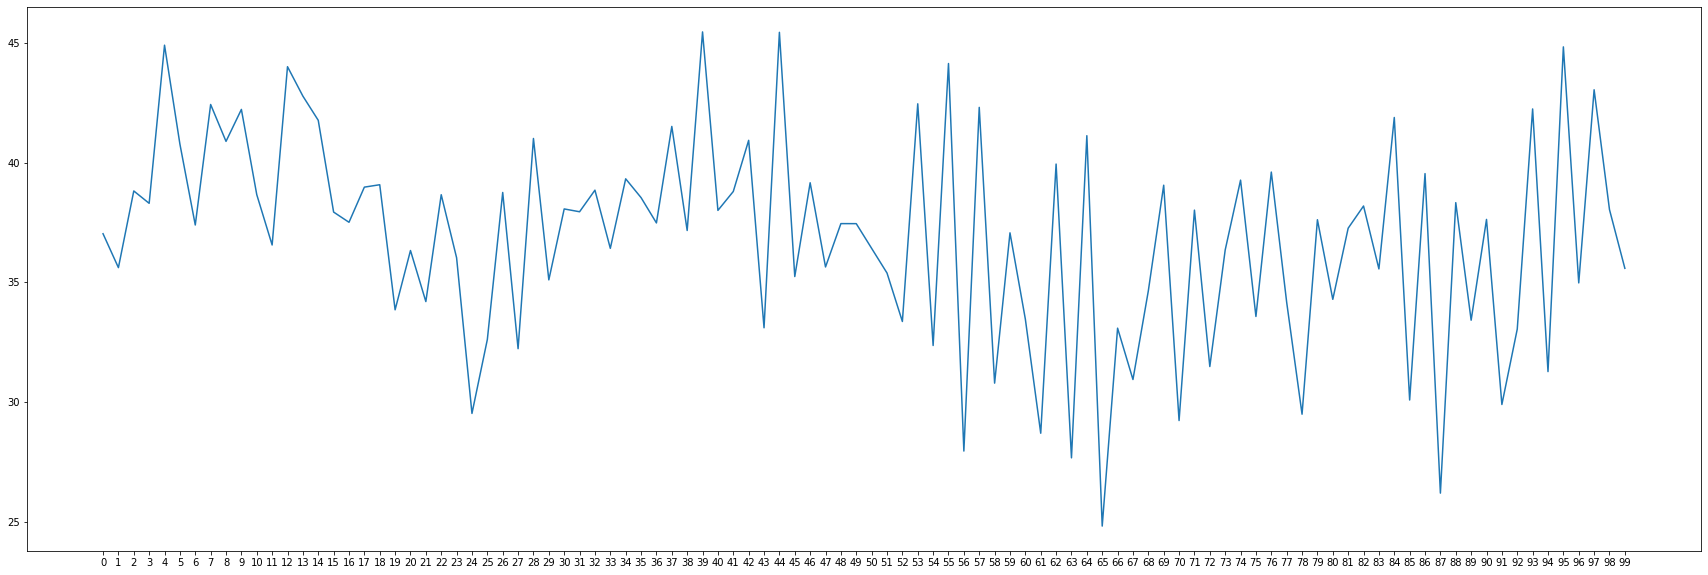

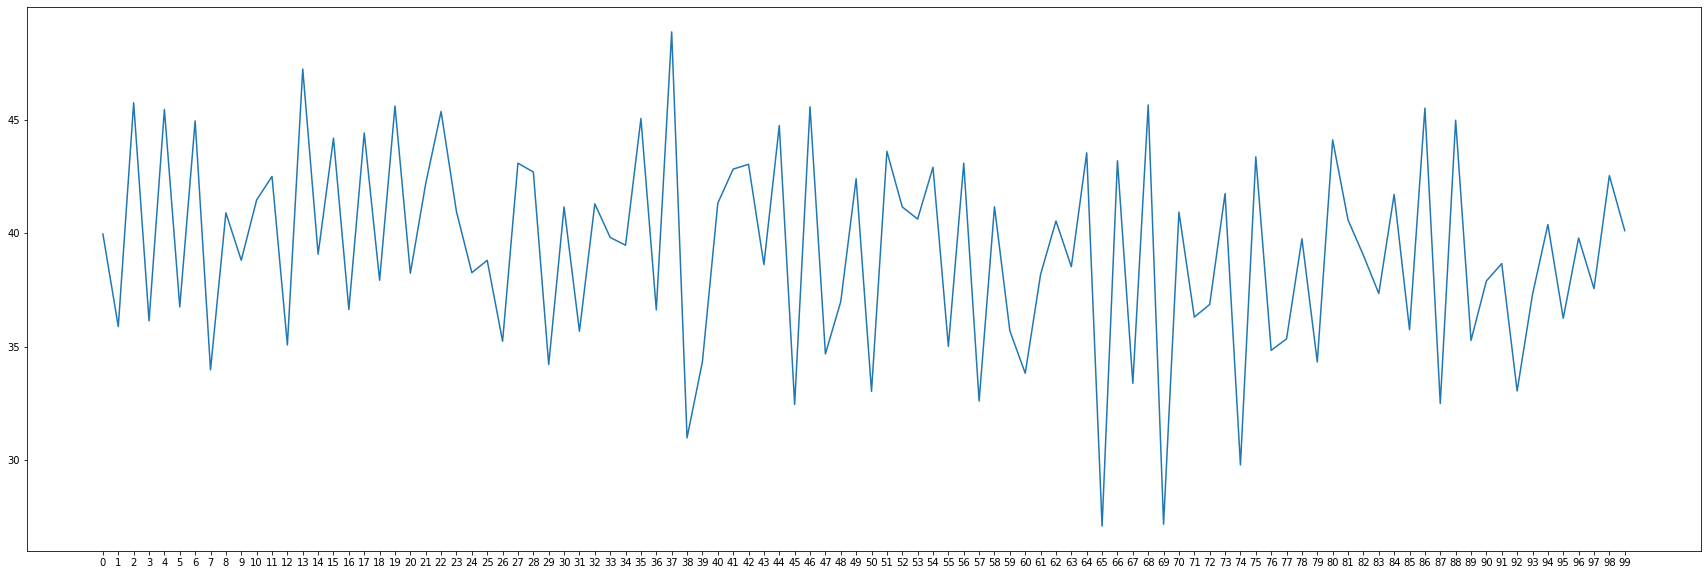

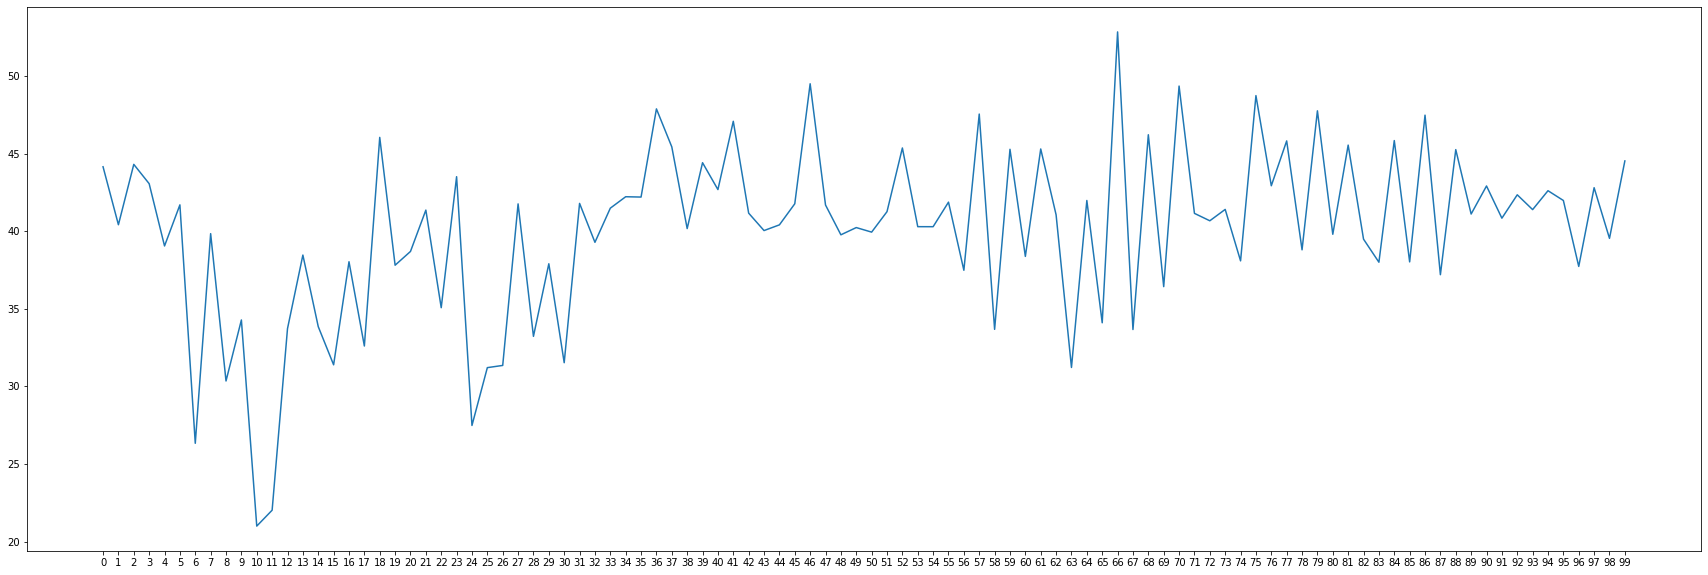

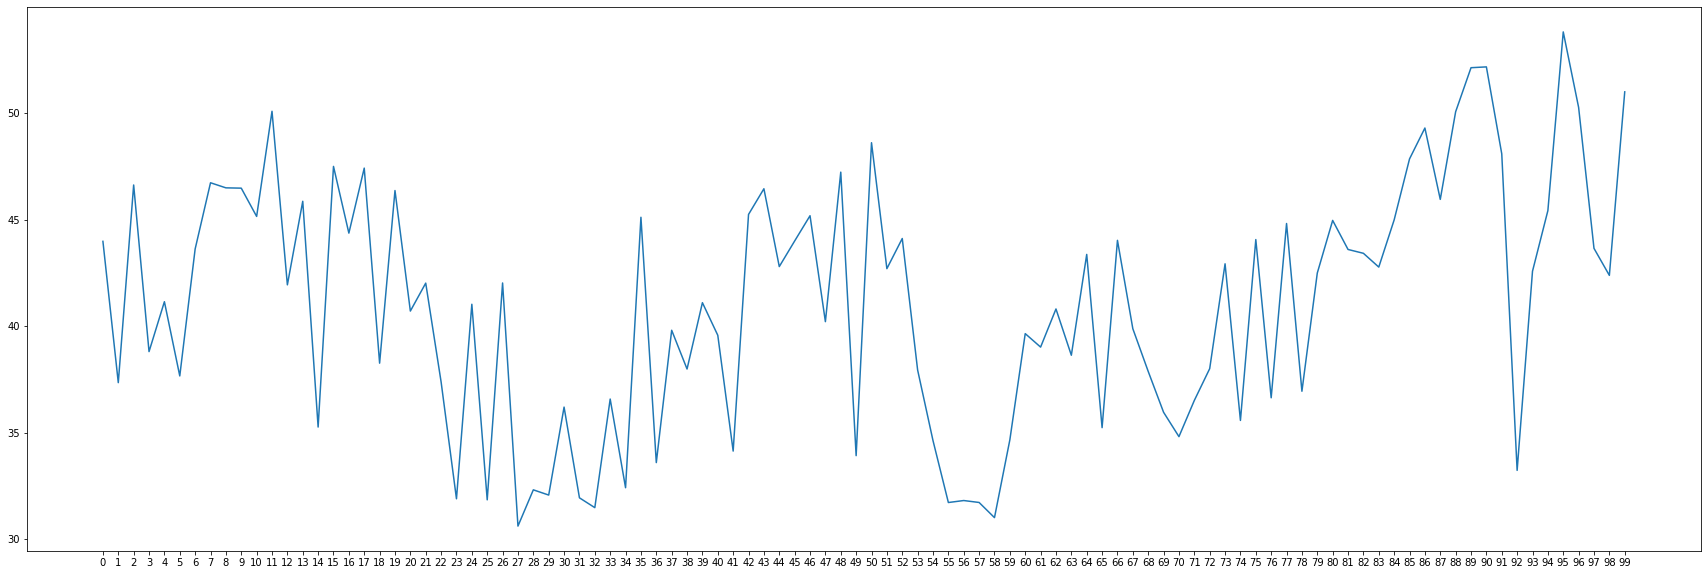

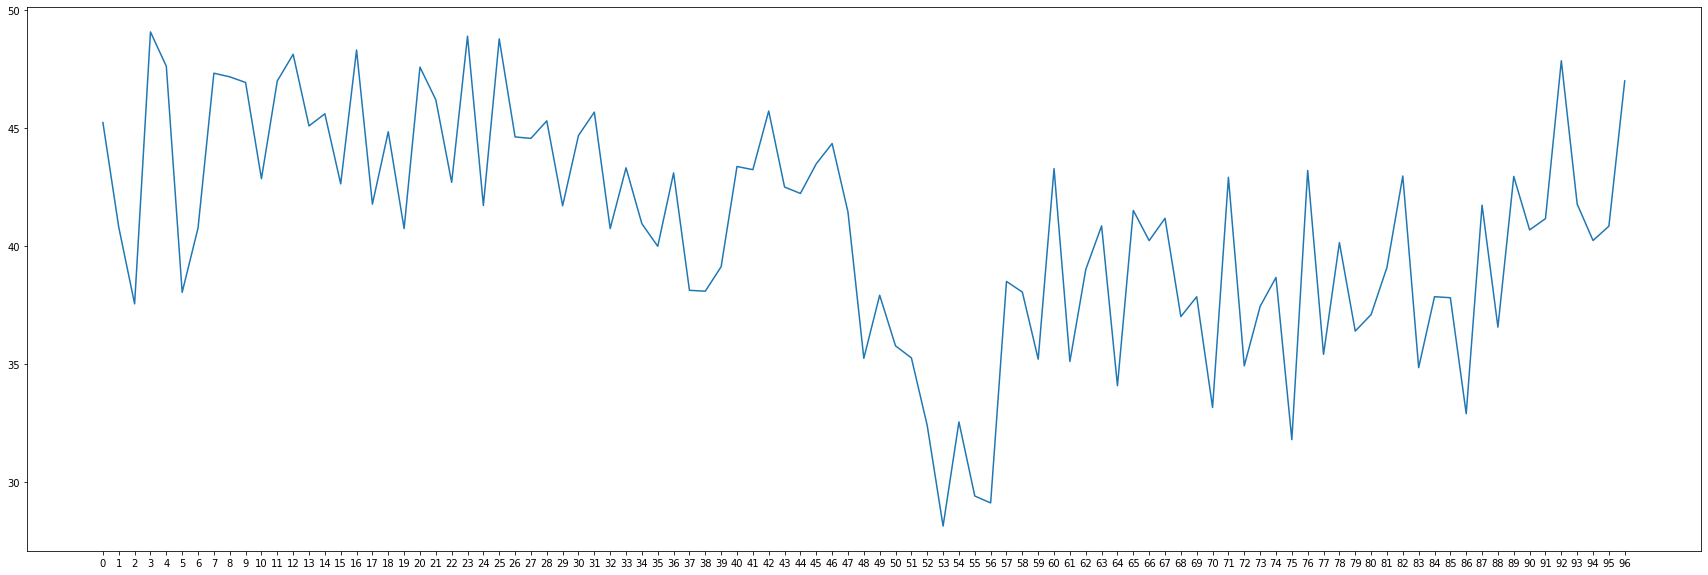

In [22]:
# ploting the average intensity of the average frames
plot_results(mse_values2)

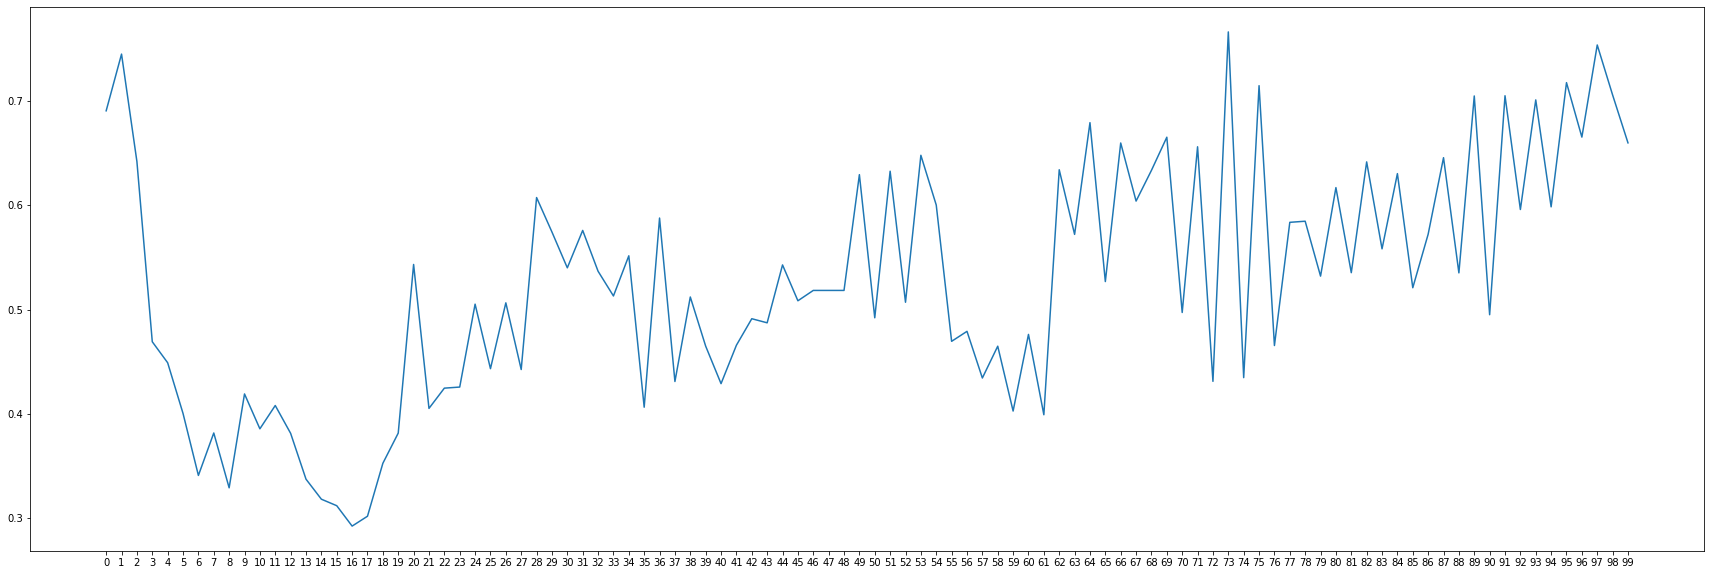

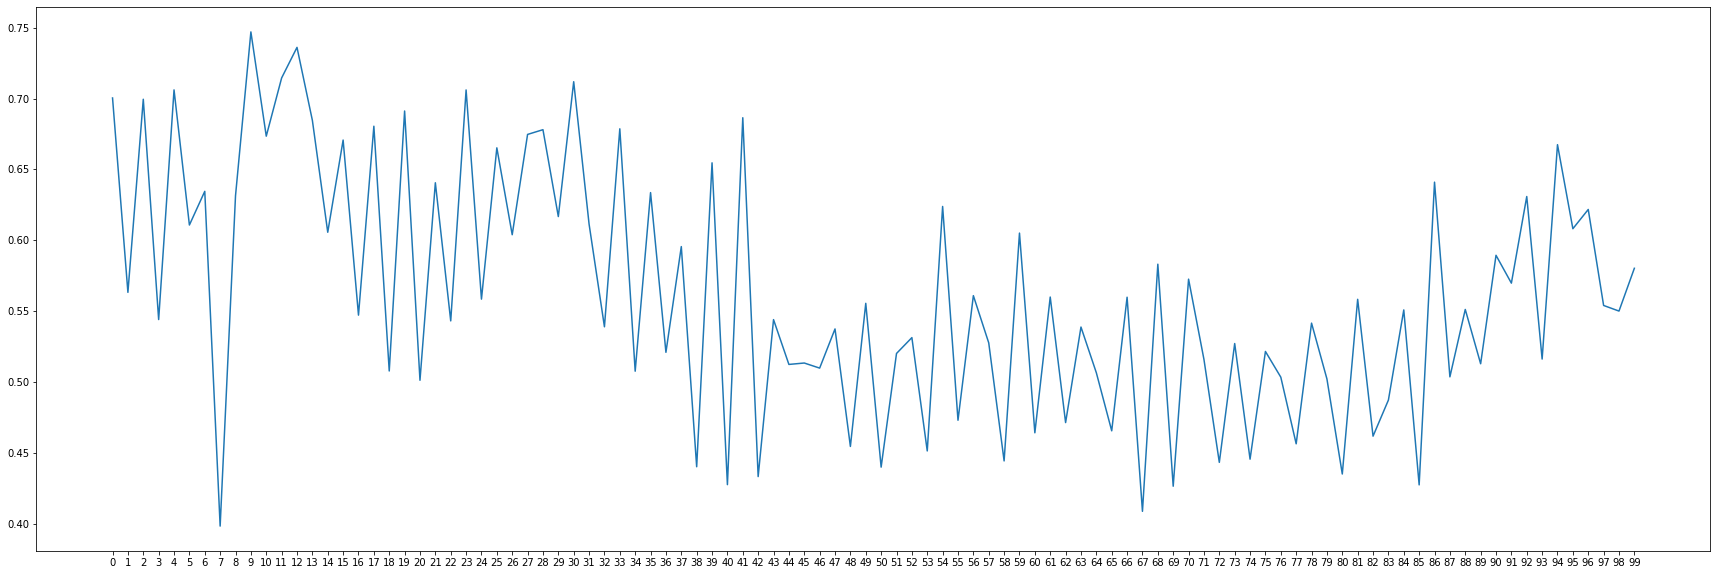

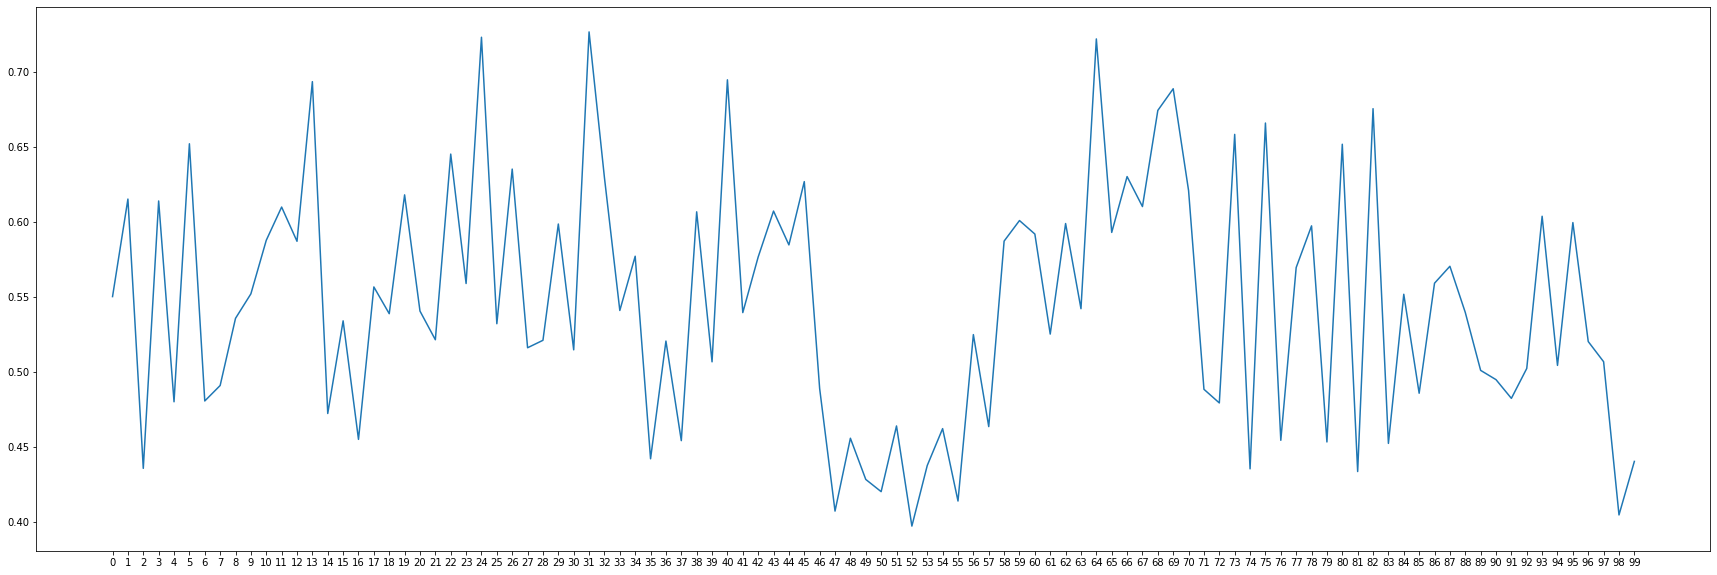

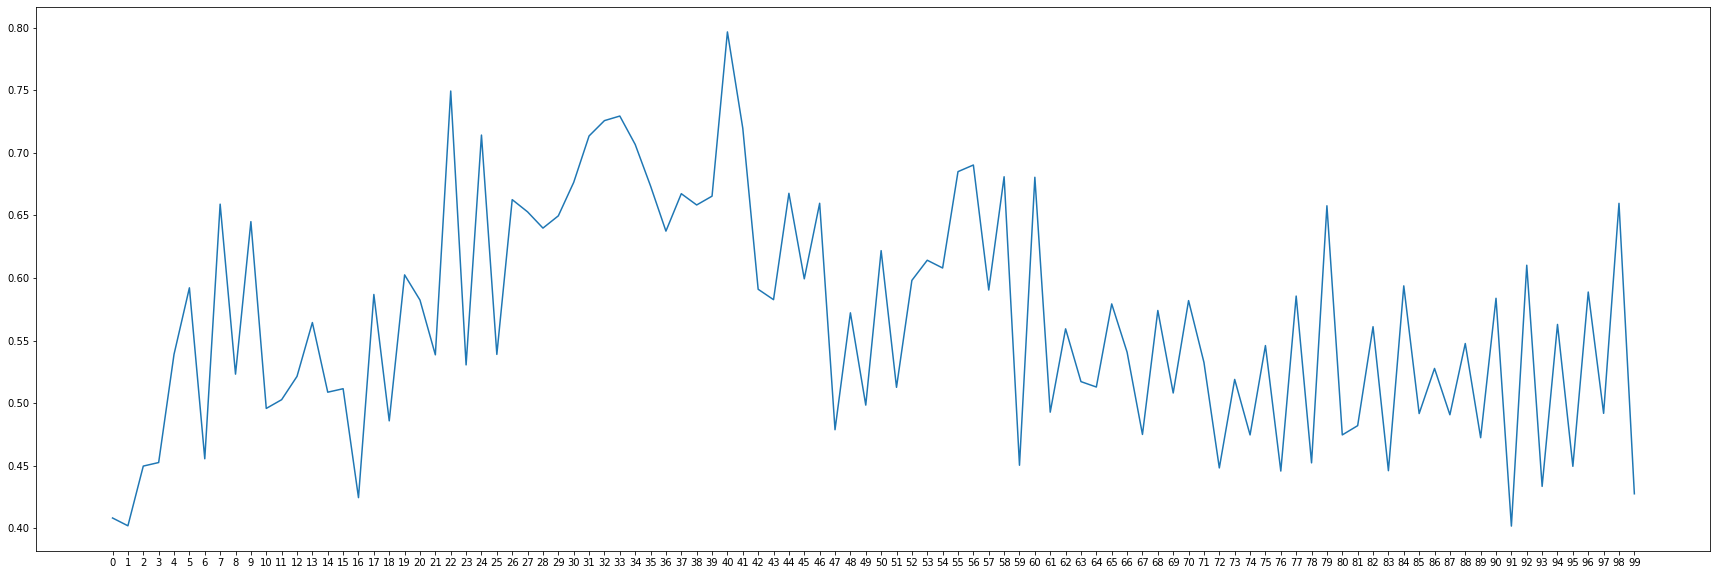

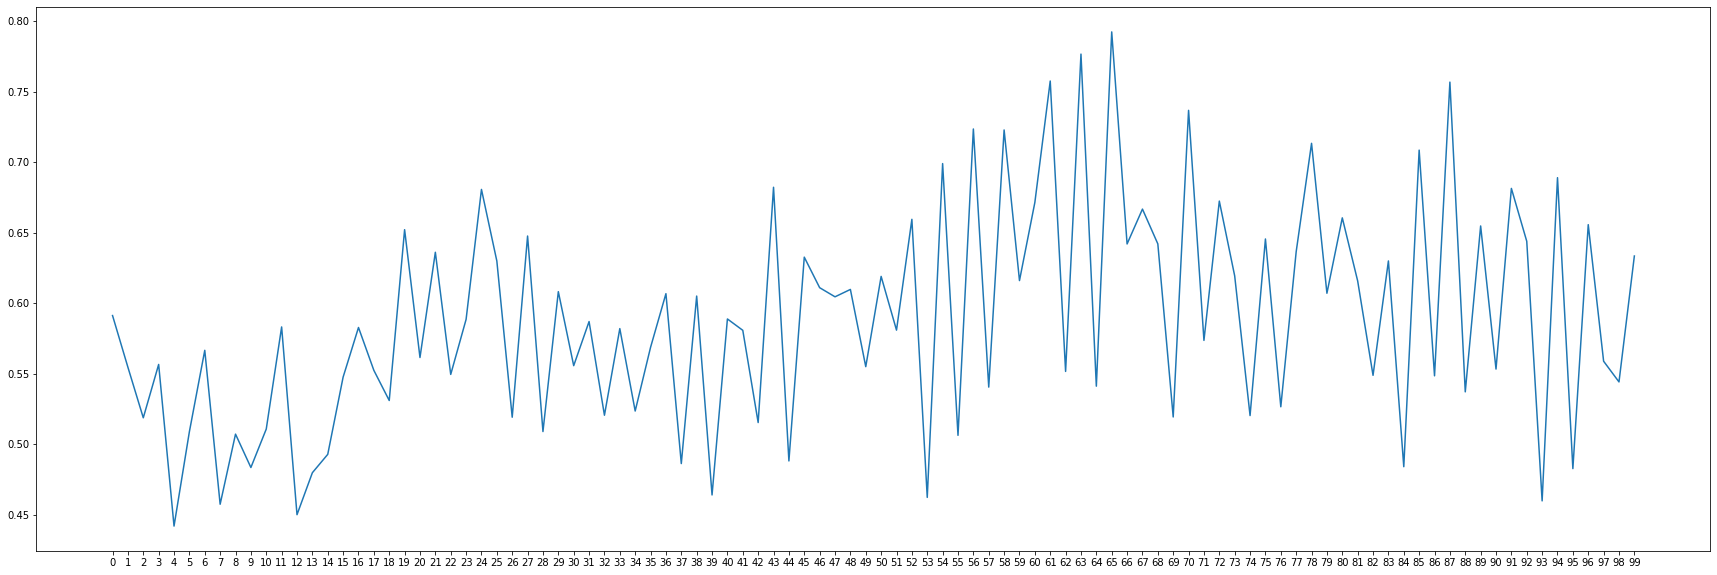

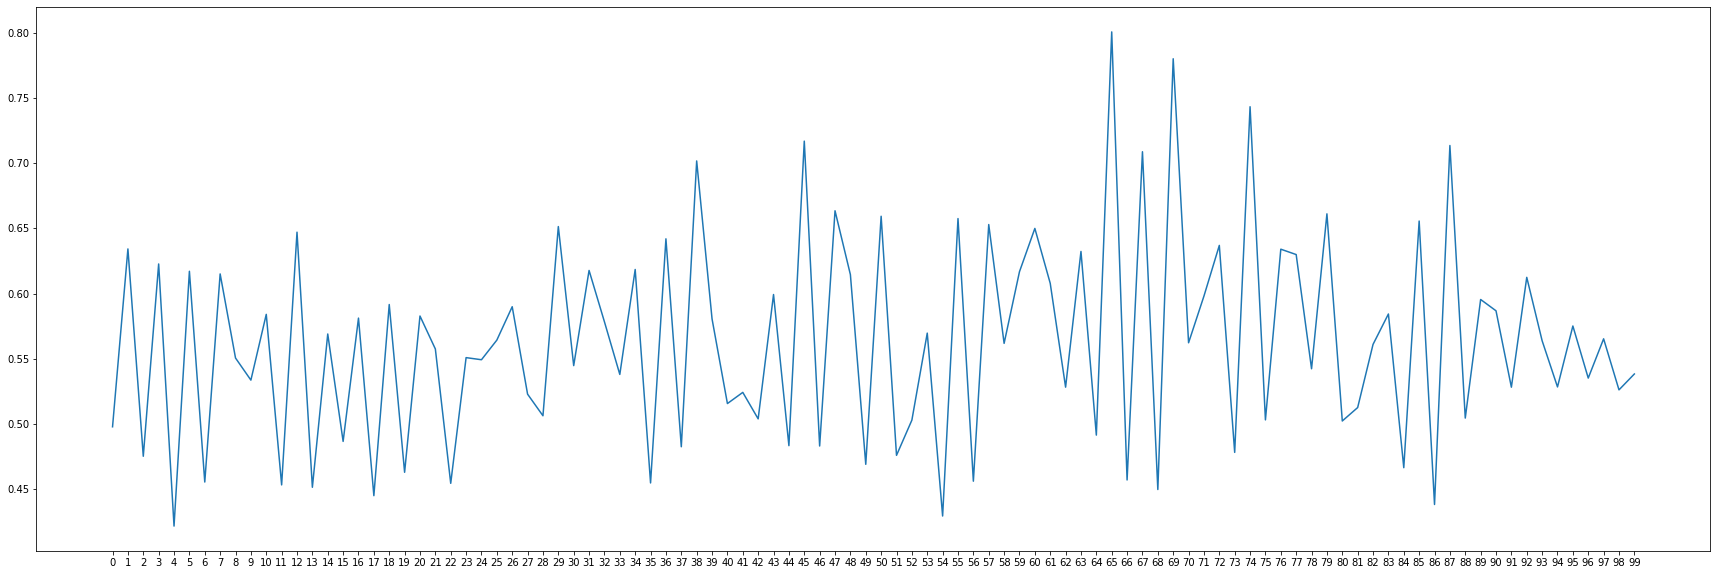

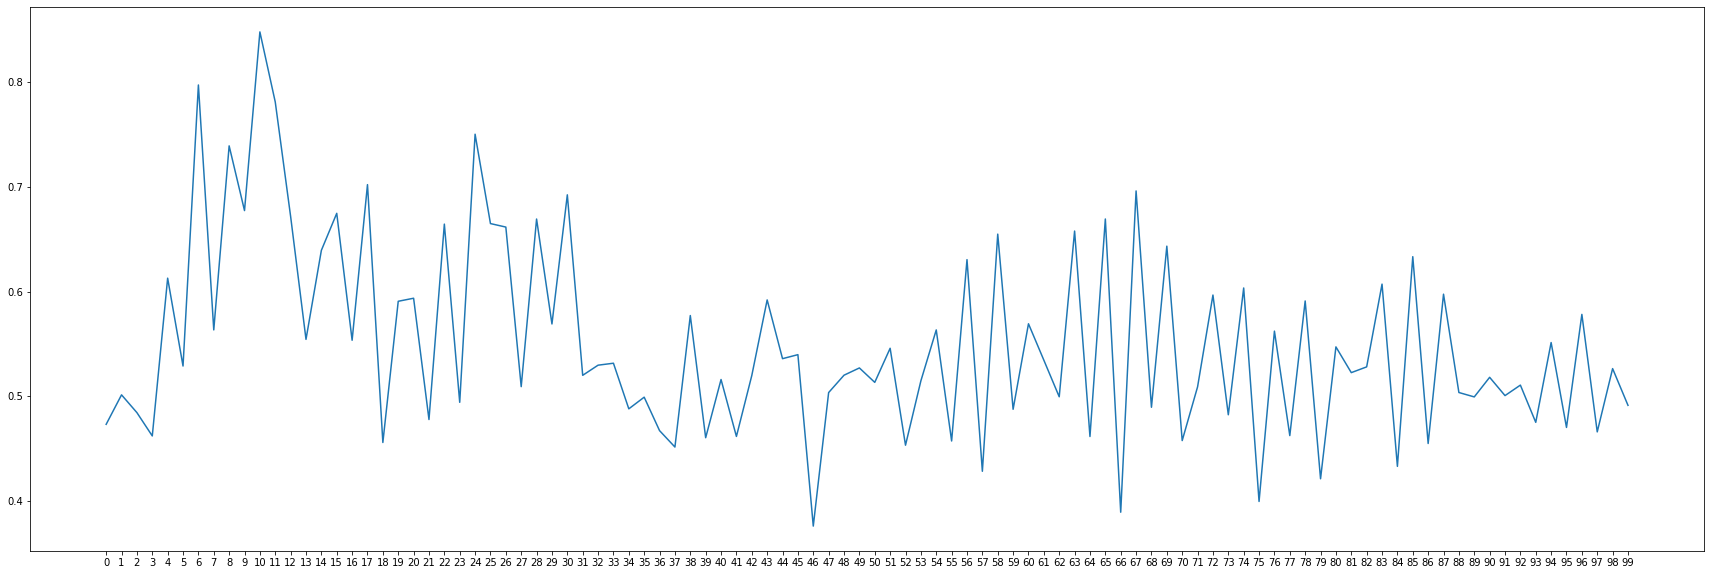

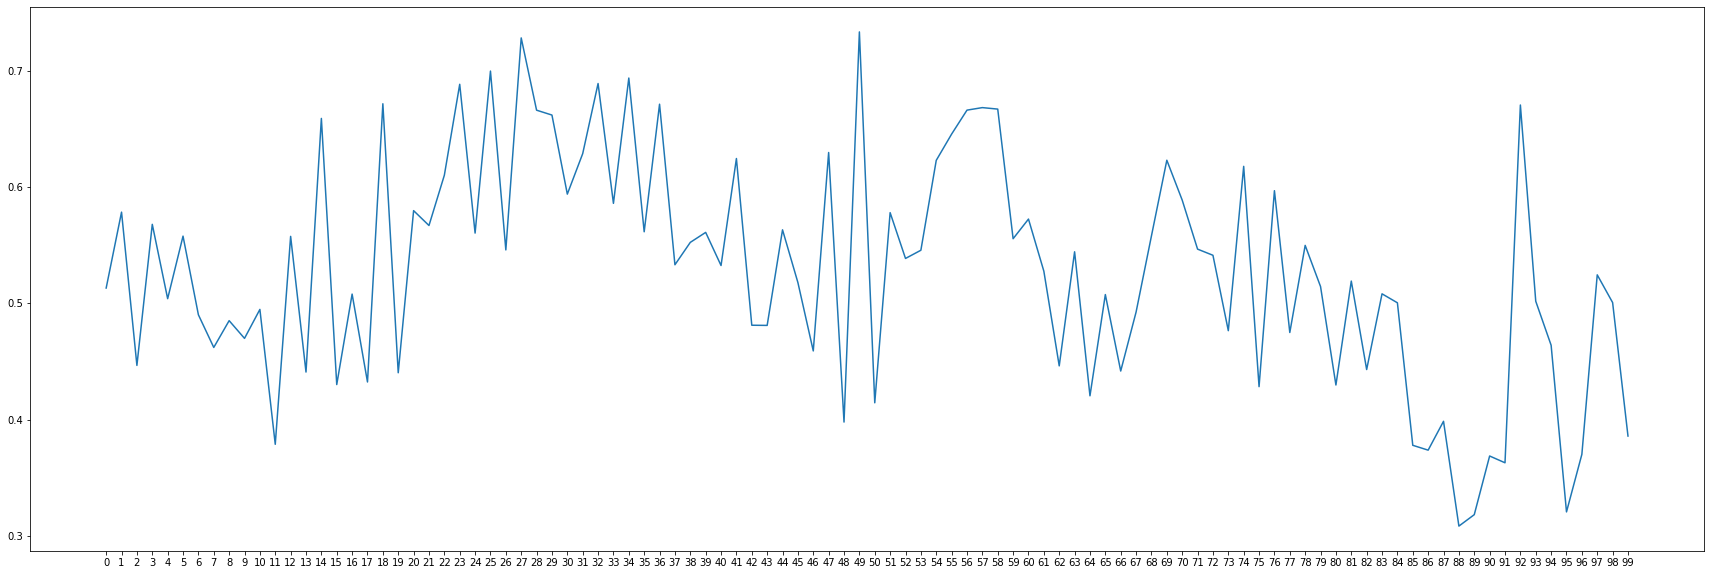

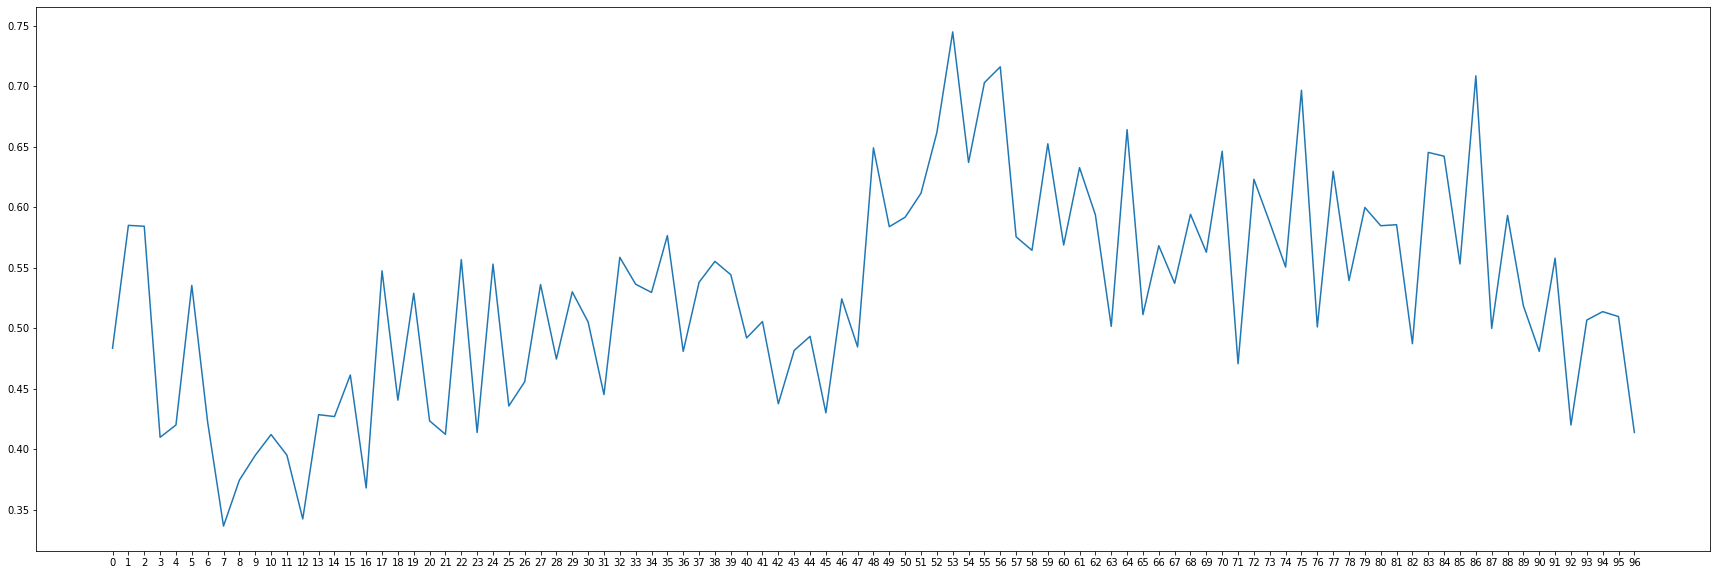

In [23]:
plot_results(ssim_values2)

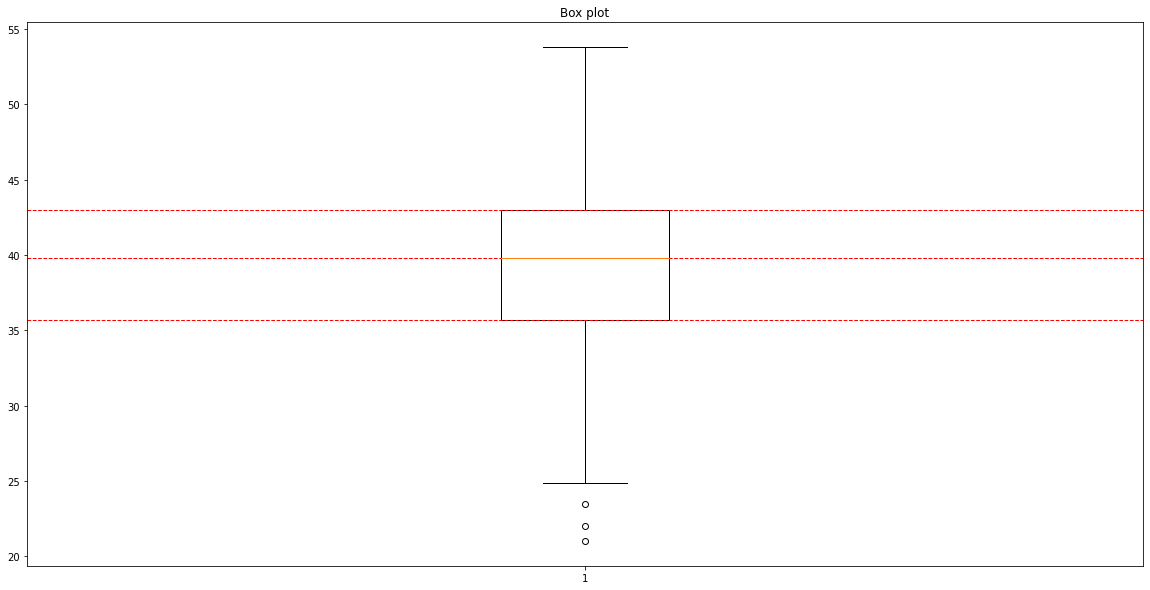

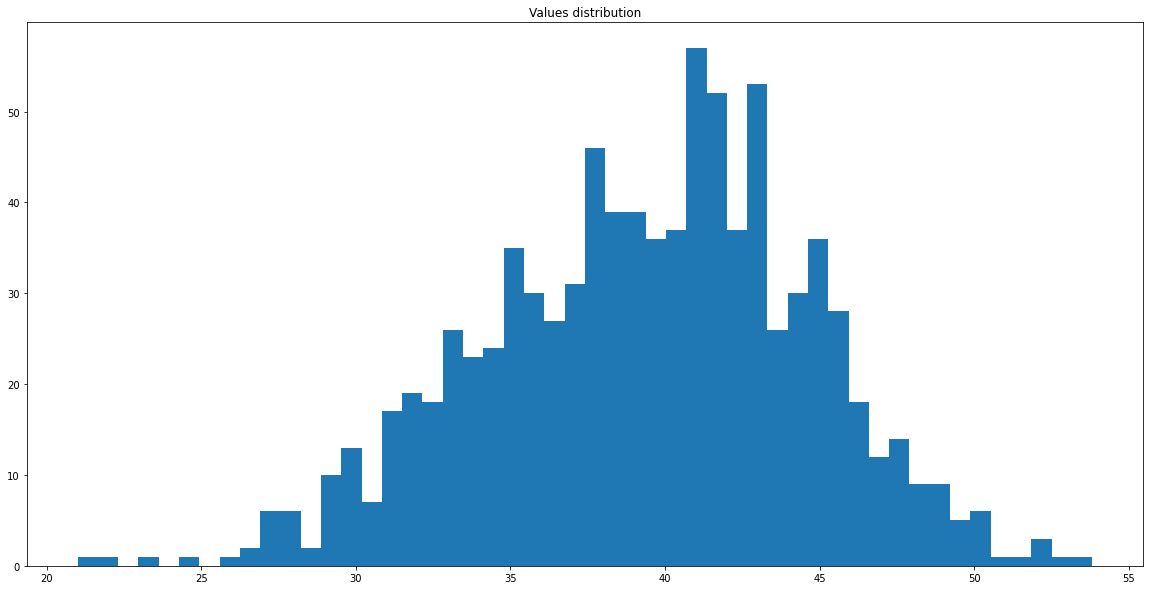

,mean,median,first quartile,third quartile,upper whisker,lower whisker,variance,standard deviation
0,39.366781,39.81645,35.683644,43.011863,54.004193,24.691314,27.31204,5.226092


In [24]:
get_statistics(mse_values2)


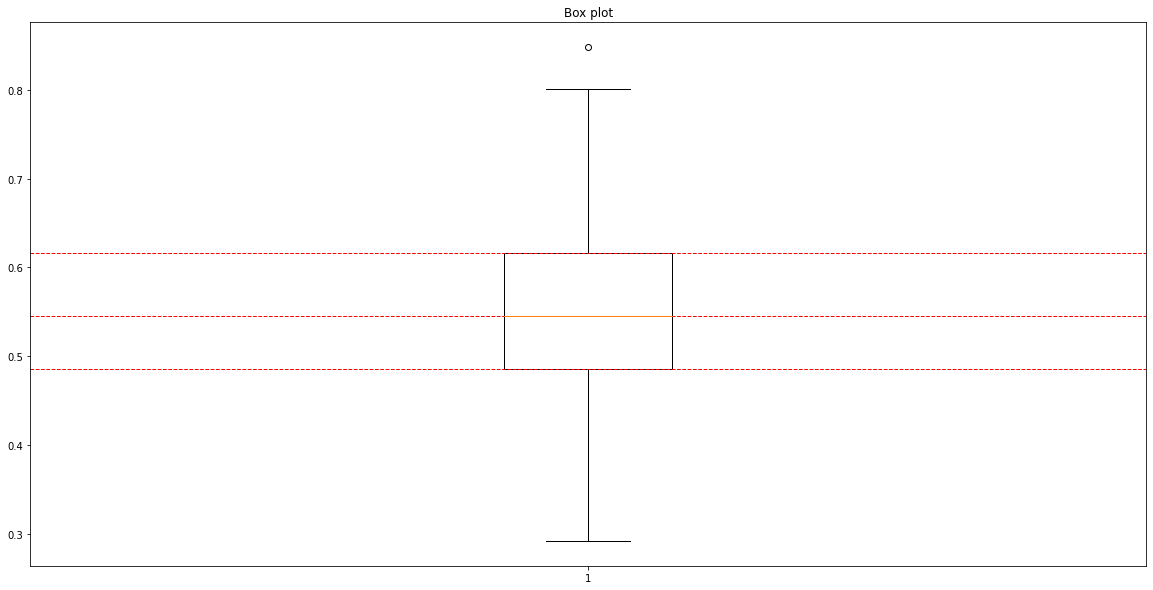

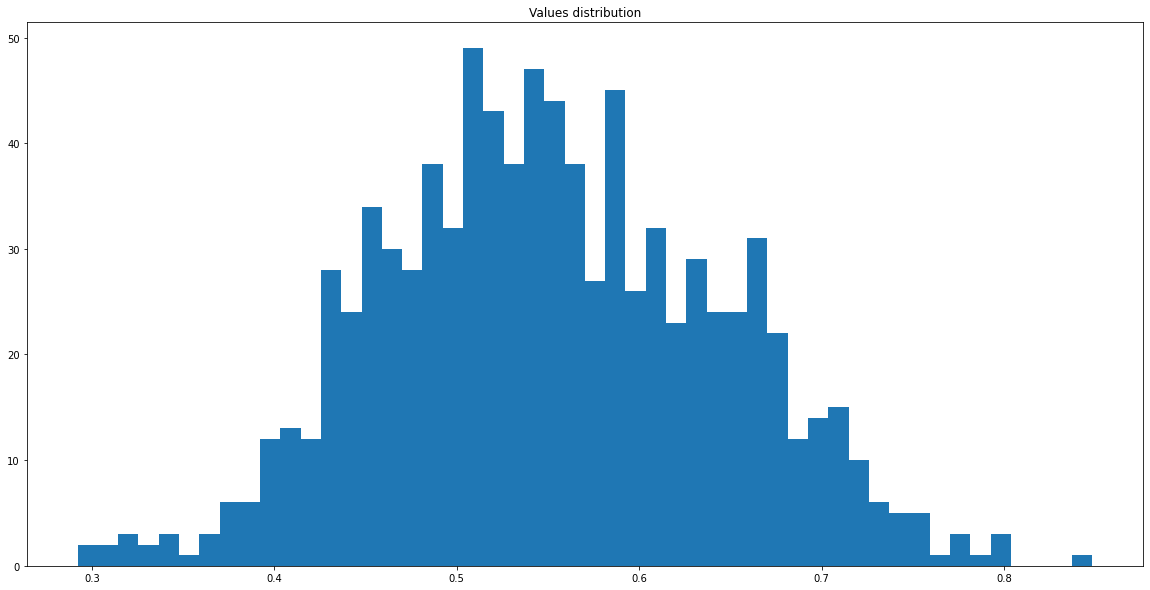

,mean,median,first quartile,third quartile,upper whisker,lower whisker,variance,standard deviation
0,0.551394,0.545975,0.485817,0.616743,0.813133,0.289427,0.008595,0.092707


In [25]:
get_statistics(ssim_values2)

In [26]:
%reset

Nothing done.
